In [2]:
#!pip -q install /kaggle/input/pytorchtabnet/pytorch_tabnet-4.1.0-py3-none-any.whl

# 1. 기존 (전처리 X)

- feature engineering, 인코딩 없이
- feature engineering 포함
- 인코딩 포함
- feature engineering, 인코딩 포함 (지금)
- 시계열 feature engineering 까지 추가
- data_preprocessing 추가

In [156]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.metrics import cohen_kappa_score, accuracy_score, mean_squared_error
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from scipy.optimize import minimize
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# from keras.models import Model
# from keras.layers import Input, Dense
# from keras.optimizers import Adam
import torch
import torch.nn as nn
import torch.optim as optim
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.callbacks import Callback

from colorama import Fore, Style
from IPython.display import clear_output
import warnings
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

SEED = 42
n_splits = 5

In [158]:
def process_file(filename, dirname):
    df = pd.read_parquet(os.path.join(dirname, filename, 'part-0.parquet'))
    df.drop('step', axis=1, inplace=True)
    return df.describe().values.reshape(-1), filename.split('=')[1]

def load_time_series(dirname) -> pd.DataFrame:
    ids = os.listdir(dirname)
    
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(lambda fname: process_file(fname, dirname), ids), total=len(ids)))
    
    stats, indexes = zip(*results)
    
    df = pd.DataFrame(stats, columns=[f"stat_{i}" for i in range(len(stats[0]))])
    df['id'] = indexes
    return df

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, encoding_dim*3),
            nn.ReLU(),
            nn.Linear(encoding_dim*3, encoding_dim*2),
            nn.ReLU(),
            nn.Linear(encoding_dim*2, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*3),
            nn.ReLU(),
            nn.Linear(input_dim*3, input_dim),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
def perform_autoencoder(df, encoding_dim=50, epochs=50, batch_size=32):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    
    data_tensor = torch.FloatTensor(df_scaled)
    
    input_dim = data_tensor.shape[1]
    autoencoder = AutoEncoder(input_dim, encoding_dim)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters())
    
    for epoch in range(epochs):
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i : i + batch_size]
            optimizer.zero_grad()
            reconstructed = autoencoder(batch)
            loss = criterion(reconstructed, batch)
            loss.backward()
            optimizer.step()
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}]')
                 
    with torch.no_grad():
        encoded_data = autoencoder.encoder(data_tensor).numpy()
        
    df_encoded = pd.DataFrame(encoded_data, columns=[f'Enc_{i + 1}' for i in range(encoded_data.shape[1])])
    
    return df_encoded

def data_preprocessing(df):
    PAQ_Total = []
    for i in range(len(df)):
        if pd.isnull(df.loc[i]['PAQ_A-PAQ_A_Total']):
            if pd.isnull(df.loc[i]['PAQ_C-PAQ_C_Total']):
                PAQ_Total.append(np.nan)
            else:
                PAQ_Total.append(df.loc[i]['PAQ_C-PAQ_C_Total'])
        else:
            PAQ_Total.append(df.loc[i]['PAQ_A-PAQ_A_Total'])
    df['PAQ_Total'] = PAQ_Total
    df = df.drop(['PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total'], axis =1)
    
    df = df.drop(['Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage'], axis =1 ) #no meaning + high variance column drop

    df = df.drop(['FGC-FGC_GSND','FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'], axis=1) #GSND, GSD column drop

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)    
    
    
    thresholds = {
        'BIA-BIA_BMC': 400,
        'BIA-BIA_BMR': 10000,
        'BIA-BIA_DEE': 9000,
        'BIA-BIA_ECW': 150,
        'BIA-BIA_FFM': 400,
        'BIA-BIA_FFMI': 100,
        'BIA-BIA_FMI': -100,
        'BIA-BIA_Fat': -1000,
        'BIA-BIA_ICW': 200,
        'BIA-BIA_LDM': 100,
        'BIA-BIA_LST': 400,
        'BIA-BIA_SMM': 300,
        'BIA-BIA_TBW': 300
    }

    for column, threshold in thresholds.items():
        condition = df[column] > threshold if threshold > 0 else df[column] < threshold
        df[column] = np.where(condition, np.nan, df[column])
    
    return df
    
def feature_engineering(df):
    season_cols = [col for col in df.columns if 'Season' in col]
    df = df.drop(season_cols, axis=1) 
    df['BMI_Age'] = df['Physical-BMI'] * df['Basic_Demos-Age']
    df['Internet_Hours_Age'] = df['PreInt_EduHx-computerinternet_hoursday'] * df['Basic_Demos-Age']
    df['BMI_Internet_Hours'] = df['Physical-BMI'] * df['PreInt_EduHx-computerinternet_hoursday']
    df['BFP_BMI'] = df['BIA-BIA_Fat'] / df['BIA-BIA_BMI']
    df['FFMI_BFP'] = df['BIA-BIA_FFMI'] / df['BIA-BIA_Fat']
    df['FMI_BFP'] = df['BIA-BIA_FMI'] / df['BIA-BIA_Fat']
    df['LST_TBW'] = df['BIA-BIA_LST'] / df['BIA-BIA_TBW']
    df['BFP_BMR'] = df['BIA-BIA_Fat'] * df['BIA-BIA_BMR']
    df['BFP_DEE'] = df['BIA-BIA_Fat'] * df['BIA-BIA_DEE']
    df['BMR_Weight'] = df['BIA-BIA_BMR'] / df['Physical-Weight']
    df['DEE_Weight'] = df['BIA-BIA_DEE'] / df['Physical-Weight']
    df['SMM_Height'] = df['BIA-BIA_SMM'] / df['Physical-Height']
    df['Muscle_to_Fat'] = df['BIA-BIA_SMM'] / df['BIA-BIA_FMI']
    df['Hydration_Status'] = df['BIA-BIA_TBW'] / df['Physical-Weight']
    df['ICW_TBW'] = df['BIA-BIA_ICW'] / df['BIA-BIA_TBW']
    
    return df

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample = pd.read_csv('data/sample_submission.csv')
# train = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/train.csv')
# test = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/test.csv')
# sample = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/sample_submission.csv')

train['Physical-Weight'] = train['Physical-Weight'].replace(0, np.nan)
test['Physical-Weight'] = test['Physical-Weight'].replace(0, np.nan)

train_ts = load_time_series("data/series_train.parquet")
test_ts = load_time_series("data/series_test.parquet")
# train_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_train.parquet")
# test_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_test.parquet")

df_train = train_ts.drop('id', axis=1)
df_test = test_ts.drop('id', axis=1)

train_ts_encoded = perform_autoencoder(df_train, encoding_dim=60, epochs=100, batch_size=32)
test_ts_encoded = perform_autoencoder(df_test, encoding_dim=60, epochs=100, batch_size=32)

time_series_cols = train_ts_encoded.columns.tolist()
train_ts_encoded["id"]=train_ts["id"]
test_ts_encoded['id']=test_ts["id"]

train = pd.merge(train, train_ts_encoded, how="left", on='id')
test = pd.merge(test, test_ts_encoded, how="left", on='id')

100%|██████████| 2/2 [00:00<00:00, 24.93it/s]


Epoch [10/100], Loss: 0.6910]
Epoch [20/100], Loss: 0.6441]
Epoch [30/100], Loss: 0.6084]
Epoch [40/100], Loss: 0.5951]
Epoch [50/100], Loss: 0.5951]
Epoch [60/100], Loss: 0.5933]
Epoch [70/100], Loss: 0.5854]
Epoch [80/100], Loss: 0.5845]
Epoch [90/100], Loss: 0.5844]
Epoch [100/100], Loss: 0.5850]
Epoch [10/100], Loss: 0.9767]
Epoch [20/100], Loss: 0.4627]
Epoch [30/100], Loss: 0.4271]
Epoch [40/100], Loss: 0.4271]
Epoch [50/100], Loss: 0.4271]
Epoch [60/100], Loss: 0.4271]
Epoch [70/100], Loss: 0.4271]
Epoch [80/100], Loss: 0.4271]
Epoch [90/100], Loss: 0.4271]
Epoch [100/100], Loss: 0.4271]


In [159]:
kid_perfect = train[train['PCIAT-PCIAT_Total']==0]
no_perfect = kid_perfect[kid_perfect['PreInt_EduHx-computerinternet_hoursday']>2].index.tolist()
print('num2', len(no_perfect))
train = train.drop(index= no_perfect)
train = train.reset_index(drop=True)

num2 5


In [160]:
# train = data_preprocessing(train)
# test = data_preprocessing(test)

In [161]:
imputer = KNNImputer(n_neighbors=5)
numeric_cols = train.select_dtypes(include=['int32', 'int64', 'float64', 'int64']).columns
imputed_data = imputer.fit_transform(train[numeric_cols])
train_imputed = pd.DataFrame(imputed_data, columns=numeric_cols)
train_imputed['sii'] = train_imputed['sii'].round().astype(int)
for col in train.columns:
    if col not in numeric_cols:
        train_imputed[col] = train[col]
        
train = train_imputed

train = feature_engineering(train)
train = train.dropna(thresh=10, axis=0)
test = feature_engineering(test)

In [162]:
train.drop('id', axis=1)
train

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,id,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,5.0,0.0,51.0,16.877316,46.00,50.80,23.0,61.2,86.4,110.6,4.0,5.8,27.0,0.0,0.0,17.56,1.8,16.18,1.4,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.668550,16.87920,932.4980,1492.000,8.255980,41.58620,13.81770,3.061430,9.213770,1.0,24.43490,8.895360,38.91770,19.54130,32.69090,1.3440,2.2220,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,48.4,62.2,3.0,2,00008ff9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,9.0,0.0,71.0,14.035590,48.00,46.00,22.0,75.0,70.0,122.0,4.6,6.6,24.2,3.0,0.0,16.04,1.6,15.50,1.6,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.579490,14.03710,936.6560,1498.650,6.019930,42.02910,12.82540,1.211720,3.970850,1.0,21.03520,14.974000,39.44970,15.41070,27.05520,2.6260,2.3400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0,000fd460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,10.0,1.0,71.0,16.648696,56.50,75.60,24.8,65.0,94.0,117.0,5.0,7.0,33.0,20.0,1.0,10.20,1.0,14.70,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,2.4,2.666232,18.20692,977.2406,1542.044,12.351336,46.35190,14.19112,4.015798,14.088110,2.6,23.75750,10.243036,43.68564,19.61508,36.10882,2.0938,2.1700,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0,00105258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.486961,20.0,33.297392,0.773778,1.007312,0.285049,1.209833,13767.473069,21724.485497,12.926463,20.397407,0.347170,4.884479,0.

In [163]:
test.drop('id', axis=1)
test

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,00008ff9,5,0,51.0,16.877316,46.00,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,000fd460,9,0,NaN,14.035590,48.00,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,2.340,46.0,64.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,00105258,10,1,71.0,16.648696,56.50,75.6,NaN,65.0,94.0,117.0,5.0,7.0,33.0,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.170,38.0,54.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.486961,20.0,33.297392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,9,0,71.0,18.292347,56.00,81.6,NaN,60.0,97.0,117.0,6.0,9.0,37.0,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,2.451,31.0,45.0,0.0,5.710085,13.609997,0.000000,0.000000,15.150139,0.0,3.501321,2.242533,9.221955,0.0,0.0,7.999233,5.369318,0.0,0.000000,8.549518,0.0,0.0,0.0,8.364371,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,3.114352,0.000000,9.092402,0.0,12.119387,0.0,5.103053,0.0,0.0,11.776683,8.481811,0.0,0.913472,0.0,0.0,0.000000,7.041000,0.0,10.707288,8.02157,0.0,7.625135,0.0,8.801978,16.043180,12.043025,0.0,0.00000,9.139127,0.000000,0.0,8.602116,164.631122,0.0,0.000000,1.028971,0.747651,0.224196,1.281264,21298.377749,36207.4115

In [164]:
featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Max_Stage',
                'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
                'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total',
                'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'sii', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

# ['Basic_Demos-Age', 'Basic_Demos-Sex',
#                 'CGAS-CGAS_Score', 'Physical-BMI',
#                 'Physical-Height', 'Physical-Weight', 
#                 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
#                 'Fitness_Endurance-Time_Mins', 
#                 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU',
#                 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
#                 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
#                 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
#                 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
#                 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
#                 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
#                 'BIA-BIA_TBW', 'PAQ_Total', 'SDS-SDS_Total_Raw',
#                 'SDS-SDS_Total_T',
#                 'PreInt_EduHx-computerinternet_hoursday', 'sii', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
#                 'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
#                 'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

## 제외 목록
#'Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage',
#'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'

featuresCols += time_series_cols

train = train[featuresCols]
train = train.dropna(subset='sii')

featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Max_Stage',
                'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
                'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total',
                'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

featuresCols += time_series_cols
test = test[featuresCols]

In [165]:
if np.any(np.isinf(train)):
    train = train.replace([np.inf, -np.inf], np.nan)

In [166]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true.round(0).astype(int), y_pred.round(0).astype(int), weights='quadratic')

def threshold_Rounder(oof_non_rounded, thresholds):
    return np.where(oof_non_rounded < thresholds[0], 0,
                    np.where(oof_non_rounded < thresholds[1], 1,
                             np.where(oof_non_rounded < thresholds[2], 2, 3)))

def evaluate_predictions(thresholds, y_true, oof_non_rounded):
    rounded_p = threshold_Rounder(oof_non_rounded, thresholds)
    return -quadratic_weighted_kappa(y_true, rounded_p)

def TrainML(model_class, test_data):
    X = train.drop(['sii'], axis=1)
    y = train['sii']

    SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    train_S = []
    test_S = []
    
    oof_non_rounded = np.zeros(len(y), dtype=float) 
    oof_rounded = np.zeros(len(y), dtype=int) 
    test_preds = np.zeros((len(test_data), n_splits))

    #for fold, (train_idx, test_idx) in enumerate(tqdm(SKF.split(X, y), desc="Training Folds", total=n_splits)):
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model = clone(model_class)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        oof_non_rounded[test_idx] = y_val_pred
        y_val_pred_rounded = y_val_pred.round(0).astype(int)
        oof_rounded[test_idx] = y_val_pred_rounded

        train_kappa = quadratic_weighted_kappa(y_train, y_train_pred.round(0).astype(int))
        val_kappa = quadratic_weighted_kappa(y_val, y_val_pred_rounded)

        train_S.append(train_kappa)
        test_S.append(val_kappa)
        
        test_preds[:, fold] = model.predict(test_data)
        
        #print(f"Fold {fold+1} - Train QWK: {train_kappa:.4f}, Validation QWK: {val_kappa:.4f}")
        #clear_output(wait=True)

    #print(f"Mean Train QWK --> {np.mean(train_S):.4f}")
    #print(f"Mean Validation QWK ---> {np.mean(test_S):.4f}")

    KappaOPtimizer = minimize(evaluate_predictions,
                              x0=[0.5, 1.5, 2.5], args=(y, oof_non_rounded), 
                              method='Nelder-Mead')
    assert KappaOPtimizer.success, "Optimization did not converge."
    
    oof_tuned = threshold_Rounder(oof_non_rounded, KappaOPtimizer.x)
    tKappa = quadratic_weighted_kappa(y, oof_tuned)

    #print(f"----> || Optimized QWK SCORE :: {Fore.CYAN}{Style.BRIGHT} {tKappa:.3f}{Style.RESET_ALL}")

    tpm = test_preds.mean(axis=1)
    tpTuned = threshold_Rounder(tpm, KappaOPtimizer.x)
    
    submission = pd.DataFrame({
        'id': sample['id'],
        'sii': tpTuned
    })

    return submission, tKappa, model

In [167]:
from sklearn.metrics import cohen_kappa_score
from pytorch_tabnet.metrics import Metric

# def quadratic_weighted_kappa(y_true, y_pred):
    
#     threshold_ = [0.5, 1.5, 2.5]
#     y_pred = np.where(y_pred < threshold_[0], 0,
#                         np.where(y_pred < threshold_[1], 1,
#                                 np.where(y_pred < threshold_[2], 2, 3)))
    
#     return cohen_kappa_score(y_true, y_pred, weights="quadratic")

class QuadraticWeightedKappaMetric(Metric):
    def __init__(self):
        self._name = "qwk"
        self._maximize = True

    def __call__(self, y_true, y_pred):
        return quadratic_weighted_kappa(y_true, y_pred.round(0).astype(int))

class TabNetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, **kwargs):
        self.model = TabNetRegressor(**kwargs)
        self.kwargs = kwargs
        self.imputer = SimpleImputer(strategy='median')
        self.best_model_path = 'best_tab_model.pt'
        
    def fit(self, X, y):
        X_imputed = self.imputer.fit_transform(X)
            
        if hasattr(y, 'values'):
            y = y.values

        X_train, X_valid, y_train, y_valid = train_test_split(X_imputed, y, test_size=0.2, random_state=SEED)

        history = self.model.fit(
            X_train=X_train,
            y_train=y_train.reshape(-1, 1),
            eval_set=[(X_valid, y_valid.reshape(-1, 1))],
            eval_name=['valid'],
            eval_metric=[QuadraticWeightedKappaMetric],
            max_epochs=500,
            patience=50,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=16,
            drop_last=False,
            callbacks=[
                TabNetPretrainedModelCheckpoint(
                    filepath=self.best_model_path,
                    monitor='valid_qwk',
                    save_best_only=True,
                    verbose=1
                )
            ]
        )

        if os.path.exists(self.best_model_path):
            self.model.load_model(self.best_model_path)
            os.remove(self.best_model_path)

        return self

    def predict(self, X):
        X_imputed = self.imputer.transform(X)
        return self.model.predict(X_imputed).flatten()

    def __deepcopy__(self, memo):
        cls = self.__class__
        result = self.__new__(cls)
        memo[id(self)] = result
        for k, v in self.__dict__.items():
            setattr(result, k, deepcopy(v, memo))

        return result

class TabNetPretrainedModelCheckpoint(Callback):
    def __init__(self, filepath, monitor='val_loss', mode='max', save_best_only=True, verbose=1):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.verbose = verbose
        self.best = float('inf') if mode == 'min' else -float('inf')
        
    def on_train_begin(self, logs=None):
        self.model = self.trainer
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        
        if (self.mode == 'min' and current < self.best) or (self.mode == 'max' and current > self.best):
            if self.verbose:
                print(f'\nEpoch {epoch}: {self.monitor} improved from {self.best:.4f} to {current:.4f}')
            self.best = current
            if self.save_best_only:
                self.model.save_model(self.filepath)

In [33]:
SEED = 42

def objective_lgbm(trial):
    param = {
        'num_leaves': trial.suggest_int('num_leaves', 300, 2000, 50),
        'max_depth': trial.suggest_int('max_depth', 8, 32), 
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1), 
        'n_estimators': trial.suggest_int('n_estimators', 800, 2000, 10), 
        #'min_child_samples': trial.suggest_int('min_child_samples', 30, 100),  
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50, 5),  
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0), 
        #'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0), 
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 0.1, 20.0), 
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.5, 1.0),  
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.5, 1.0), 
        #'min_gain_to_split': trial.suggest_loguniform('min_gain_to_split', 1e-8, 1.0),  
        'random_state': SEED,
    }

    submission, qwk_score, _ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_lgbm = optuna.create_study(direction='maximize', sampler=sampler)
study_lgbm.optimize(objective_lgbm, n_trials=100)

print("Best LGBM params: ", study_lgbm.best_params)
print("Best LGBM score: ", study_lgbm.best_value)

[I 2024-10-31 12:58:39,573] A new study created in memory with name: no-name-1519365e-4e96-4d0c-81d6-bc0b73f53e32
[I 2024-10-31 12:59:27,212] Trial 0 finished with value: 0.52140882926235 and parameters: {'num_leaves': 950, 'max_depth': 31, 'learning_rate': 0.015702970884055395, 'n_estimators': 1520, 'min_data_in_leaf': 10, 'subsample': 0.5779972601681014, 'reg_alpha': 0.1360354613611808, 'reg_lambda': 0.08499808989182997, 'feature_fraction': 0.8005575058716043, 'bagging_fraction': 0.8540362888980227}. Best is trial 0 with value: 0.52140882926235.
[W 2024-10-31 12:59:30,013] Trial 1 failed with parameters: {'num_leaves': 300, 'max_depth': 32, 'learning_rate': 0.03142880890840111, 'n_estimators': 1050, 'min_data_in_leaf': 10, 'subsample': 0.5917022549267169, 'reg_alpha': 0.5012686302434877, 'reg_lambda': 0.00015777981883364995, 'feature_fraction': 0.7159725093210578, 'bagging_fraction': 0.645614570099021} because of the following error: KeyboardInterrupt().
Traceback (most recent call l

KeyboardInterrupt: 

In [14]:
# https://docs.getml.com/1.1.0/api/getml.predictors.XGBoostRegressor.html

def objective_xgb(trial):

    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'random_state': SEED,
        #'device': 'cuda'
    }

    submission, qwk_score,_ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose = -1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=100)

print("Best XGB params: ", study_xgb.best_params)
print("Best XGB score: ", study_xgb.best_value)

Training Folds:  20%|██        | 1/5 [00:04<00:16,  4.14s/it]
[W 2024-10-31 12:39:24,746] Trial 0 failed with parameters: {'max_depth': 13, 'n_estimators': 1920, 'learning_rate': 0.015702970884055395, 'reg_alpha': 0.09846738873614563, 'reg_lambda': 0.00042079886696066364, 'colsample_bylevel': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'min_child_weight': 8.795585311974417, 'subsample': 0.6410035105688879} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\USER\anaconda3\envs\kaggle\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_15404\253788705.py", line 19, in objective_xgb
    submission, qwk_score,_ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose = -1), test)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USE

KeyboardInterrupt: 

In [29]:
# https://catboost.ai/en/docs/concepts/python-reference_catboostregressor

def objective_cat(trial):

    param = {
        'iterations':trial.suggest_int("iterations", 100, 500, 50),
        #'od_wait':trial.suggest_int('od_wait', 500, 2300, 50),
        'learning_rate' : trial.suggest_uniform('learning_rate',1e-4, 1),
        'reg_lambda': trial.suggest_uniform('reg_lambda',1e-5,100),
        #'subsample': trial.suggest_uniform('subsample',0,1),
        #'random_strength': trial.suggest_uniform('random_strength',10,50),
        'depth': trial.suggest_int('depth',1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf',1,30),
        #'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations',1,15),
        #'bagging_temperature' :trial.suggest_loguniform('bagging_temperature', 0.01, 100.00),
        #'colsample_bylevel':trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'random_state': SEED,
        #'task_type': 'GPU'
    }

    submission, qwk_score,_ = TrainML(CatBoostRegressor(**param,verbose=0), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_cat = optuna.create_study(direction='maximize', sampler=sampler)
study_cat.optimize(objective_cat, n_trials=100)

print("Best CAT params: ", study_cat.best_params)
print("Best CAT score: ", study_cat.best_value)

[I 2024-10-31 12:53:13,977] A new study created in memory with name: no-name-4c835000-6ee1-4ab2-800e-40391ef08aed
[I 2024-10-31 12:53:19,678] Trial 0 finished with value: 0.49339184592477203 and parameters: {'iterations': 250, 'learning_rate': 0.9507192349792751, 'reg_lambda': 73.1993968612011, 'depth': 6, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.49339184592477203.
[W 2024-10-31 12:53:21,416] Trial 1 failed with parameters: {'iterations': 150, 'learning_rate': 0.05817780380698265, 'reg_lambda': 86.61761591573206, 'depth': 7, 'min_data_in_leaf': 22} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\USER\anaconda3\envs\kaggle\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_15404\2426854716.py", line 21, in objective_cat
    submission, qwk_score,_ = TrainML(CatBoostRegressor(**par

KeyboardInterrupt: 

In [75]:
# https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

from sklearn.ensemble import ExtraTreesRegressor

train = train.fillna(-999)
test = test.fillna(-999)

def objective_et(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, 10),
        #'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state': SEED
    }
    
    submission, qwk_score,_ = TrainML(ExtraTreesRegressor(**param, n_jobs=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_et = optuna.create_study(direction='maximize', sampler=sampler)
study_et.optimize(objective_et, n_trials=100)

print("Best ET params: ", study_et.best_params)
print("Best ET score: ", study_et.best_value)

[I 2024-10-31 13:38:12,234] A new study created in memory with name: no-name-7a5029ba-e64a-4aff-a440-596f3124e395
[I 2024-10-31 13:38:16,291] Trial 0 finished with value: 0.5271985760600356 and parameters: {'n_estimators': 440, 'min_samples_split': 20, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.5271985760600356.
[I 2024-10-31 13:38:24,396] Trial 1 finished with value: 0.5348426219047264 and parameters: {'n_estimators': 640, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.5348426219047264.
[I 2024-10-31 13:38:26,161] Trial 2 finished with value: 0.5215936895106068 and parameters: {'n_estimators': 150, 'min_samples_split': 18, 'min_samples_leaf': 13}. Best is trial 1 with value: 0.5348426219047264.
[W 2024-10-31 13:38:30,098] Trial 3 failed with parameters: {'n_estimators': 740, 'min_samples_split': 2, 'min_samples_leaf': 20} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\USER\anaconda3\en

KeyboardInterrupt: 

In [ ]:
# def objective_TabNet(trial):

#     param = {
#         'n_d': trial.suggest_int("n_d", 16, 256, 16),              # Width of the decision prediction layer
#         'n_a': trial.suggest_int("n_a", 16, 256, 16),                # Width of the attention embedding for each step
#         'n_steps': trial.suggest_int("n_steps", 3, 10),            # Number of steps in the architecture
#         'gamma': trial.suggest_uniform('gamma',1,3),           # Coefficient for feature selection regularization
#         'n_independent': trial.suggest_int("n_steps", 1, 5),     # Number of independent GLU layer in each GLU block
#         'n_shared': trial.suggest_int("n_steps", 1, 5),          # Number of shared GLU layer in each GLU block
#         'lambda_sparse': 1e-4,  # Sparsity regularization
#         'optimizer_fn': torch.optim.Adam,
#         'optimizer_params': dict(lr=2e-2, weight_decay=1e-5),
#         'mask_type': 'entmax',
#         'scheduler_params': dict(mode="min", patience=10, min_lr=1e-5, factor=0.5),
#         'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
#         'verbose': 1,
#         'device_name': 'cuda' if torch.cuda.is_available() else 'cpu'
#     }

#     submission, qwk_score,_ = TrainML(TabNetWrapper(**param), test)
    
#     return qwk_score

# sampler = TPESampler(seed=42)
# study_TabNet = optuna.create_study(direction='maximize', sampler=sampler)
# study_TabNet.optimize(objective_TabNet, n_trials=100)

# print("Best TabNet params: ", study_TabNet.best_params)
# print("Best TabNet score: ", study_TabNet.best_value)

[I 2024-10-31 13:31:17,720] A new study created in memory with name: no-name-5a2e1686-f804-4d82-a141-29b933411dd6


epoch 0  | loss: 1.97037 | valid_qwk: 0.03563 |  0:01:05s
Successfully saved model at best_tab_model.pt.zip
epoch 1  | loss: 1.09283 | valid_qwk: -0.03956|  0:02:11s


[W 2024-10-31 13:33:39,344] Trial 0 failed with parameters: {'n_d': 96, 'n_a': 256, 'n_steps': 8, 'gamma': 2.197316968394073} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\USER\anaconda3\envs\kaggle\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_15404\177649333.py", line 20, in objective_TabNet
    submission, qwk_score,_ = TrainML(TabNetWrapper(**param), test)
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_15404\2306322674.py", line 32, in TrainML
    model.fit(X_train, y_train)
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_15404\3256834519.py", line 36, in fit
    history = self.model.fit(
              ^^^^^^^^^^^^^^^
  File "c:\Users\USER\anaconda3\envs\kaggle\Lib\site-packages\pytorch_tabnet\abstract_model.p

KeyboardInterrupt: 

In [168]:
LGBM_Params = {'num_leaves': 1900, 'max_depth': 22, 'learning_rate': 0.011793704071476946, 'n_estimators': 1230, 'min_data_in_leaf': 50, 'subsample': 0.501201431580586, 'reg_alpha': 5.8218416194486915, 'reg_lambda': 0.006713831091724063, 'feature_fraction': 0.7288815325434047, 'bagging_fraction': 0.6226086903049898}
#Best LGBM score:  0.5571456994396708

XGB_Params = {'max_depth': 19, 'n_estimators': 760, 'learning_rate': 0.07133633470470742, 'reg_alpha': 6.6219204699810685, 'reg_lambda': 0.02645580509101031, 'colsample_bylevel': 0.7161089285092355, 'colsample_bytree': 0.5716600913578502, 'min_child_weight': 7.894997550221044, 'subsample': 0.3107388629115943}
#Best XGB score:  0.5536951606953345

CatBoost_Params = {'iterations': 400, 'learning_rate': 0.22986991404672466, 'reg_lambda': 55.773171001118044, 'depth': 7, 'min_data_in_leaf': 2}
#Best CAT score:  0.5391257527529776

ET_Params = {'n_estimators': 530, 'min_samples_split': 6, 'min_samples_leaf': 4}
#Best ET score:  0.5392784109973567

TabNet_Params = {
    'n_d': 64,              # Width of the decision prediction layer
    'n_a': 64,              # Width of the attention embedding for each step
    'n_steps': 5,           # Number of steps in the architecture
    'gamma': 1.5,           # Coefficient for feature selection regularization
    'n_independent': 2,     # Number of independent GLU layer in each GLU block
    'n_shared': 2,          # Number of shared GLU layer in each GLU block
    'lambda_sparse': 1e-4,  # Sparsity regularization
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2, weight_decay=1e-5),
    'mask_type': 'entmax',
    'scheduler_params': dict(mode="min", patience=10, min_lr=1e-5, factor=0.5),
    'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    'verbose': 1,
    'device_name': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create model instances
Light = LGBMRegressor(**LGBM_Params, random_state=SEED, verbose=-1)
XGB_Model = XGBRegressor(**XGB_Params, random_state=SEED)
CatBoost_Model = CatBoostRegressor(**CatBoost_Params, random_state=SEED, verbose=0)
ET_Model = ExtraTreesRegressor(**ET_Params, random_state=SEED)
#TabNet_Model = TabNetWrapper(**TabNet_Params)

# Combine models using Voting Regressor
voting_model = VotingRegressor(estimators=[
    ('lightgbm', Light),
    ('xgboost', XGB_Model),
    ('catboost', CatBoost_Model),
    #('tabnet', TabNet_Model),
    ('et', ET_Model),
])

In [171]:
Submission_Light, qwk_score_Light, model_trained_Light = TrainML(Light, test)
qwk_score_Light

0.5457636086552697

In [172]:
Submission_XGB, qwk_score_XGB, model_trained_XGB = TrainML(XGB_Model, test)
qwk_score_XGB

0.5301506673386238

In [170]:
Submission_Cat, qwk_score_Cat, model_trained_Cat = TrainML(CatBoost_Model, test)
qwk_score_Cat

0.5295799145982104

In [ ]:
#Submission_TabNet, qwk_score_TabNet, model_trained_TabNet = TrainML(TabNet_Model, test)

In [174]:
# extratree는 결측치를 자동으로 처리 안함
train = train.fillna(-999)
test = test.fillna(-999)

Submission_ET, qwk_score_ET, model_trained_ET = TrainML(ET_Model, test)
qwk_score_ET

0.5298836643941957

In [ ]:
Submission_Light = Submission_Light.rename(columns={'sii': 'sii_Light'})
Submission_XGB_Model = Submission_XGB.rename(columns={'sii': 'sii_XGB'})
Submission_CatBoost_Model = Submission_Cat.rename(columns={'sii': 'sii_CatBoost'})
Submission_ET_Model = Submission_ET.rename(columns={'sii': 'sii_ET'})
Submission_TabNet_Model = Submission_TabNet.rename(columns={'sii': 'sii_TabNet'})

merged_df = Submission_Light.merge(Submission_XGB, on='id') \
                            .merge(Submission_Cat, on='id') \
                            .merge(Submission_ET, on='id') \
                            .merge(Submission_TabNet, on='id')

merged_df

,id,sii_Light,sii_XGB,sii_CatBoost,sii_ET,sii_TabNet
0,00008ff9,1,1,1,0,1
1,000fd460,1,0,0,0,0
2,105258,1,1,1,1,0
3,00115b9f,1,0,1,0,3
4,0016bb22,0,2,0,0,1
5,001f3379,1,1,1,1,1
6,0038ba98,1,1,1,1,1
7,0068a485,0,1,0,0,0
8,0069fbed,1,2,1,1,1
9,0083e397,0,2,0,0,0


In [175]:
Submission, qwk_score, model_trained = TrainML(voting_model, test)

Submission.to_csv('submission.csv', index=False)
Submission

,id,sii
0,00008ff9,1
1,000fd460,1
2,105258,1
3,00115b9f,1
4,0016bb22,1
5,001f3379,1
6,0038ba98,1
7,0068a485,0
8,0069fbed,1
9,0083e397,1


In [176]:
qwk_score

0.5503221750878864

# 2. 기존 (전처리 포함)

- feature engineering, 인코딩 없이
- feature engineering 포함
- 인코딩 포함
- feature engineering, 인코딩 포함 
- 시계열 feature engineering 까지 추가
- data_preprocessing 추가 (지금)

In [177]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.metrics import cohen_kappa_score, accuracy_score, mean_squared_error
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from scipy.optimize import minimize
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# from keras.models import Model
# from keras.layers import Input, Dense
# from keras.optimizers import Adam
import torch
import torch.nn as nn
import torch.optim as optim
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.callbacks import Callback

from colorama import Fore, Style
from IPython.display import clear_output
import warnings
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

SEED = 42
n_splits = 5
def process_file(filename, dirname):
    df = pd.read_parquet(os.path.join(dirname, filename, 'part-0.parquet'))
    df.drop('step', axis=1, inplace=True)
    return df.describe().values.reshape(-1), filename.split('=')[1]

def load_time_series(dirname) -> pd.DataFrame:
    ids = os.listdir(dirname)
    
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(lambda fname: process_file(fname, dirname), ids), total=len(ids)))
    
    stats, indexes = zip(*results)
    
    df = pd.DataFrame(stats, columns=[f"stat_{i}" for i in range(len(stats[0]))])
    df['id'] = indexes
    return df

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, encoding_dim*3),
            nn.ReLU(),
            nn.Linear(encoding_dim*3, encoding_dim*2),
            nn.ReLU(),
            nn.Linear(encoding_dim*2, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*3),
            nn.ReLU(),
            nn.Linear(input_dim*3, input_dim),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
def perform_autoencoder(df, encoding_dim=50, epochs=50, batch_size=32):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    
    data_tensor = torch.FloatTensor(df_scaled)
    
    input_dim = data_tensor.shape[1]
    autoencoder = AutoEncoder(input_dim, encoding_dim)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters())
    
    for epoch in range(epochs):
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i : i + batch_size]
            optimizer.zero_grad()
            reconstructed = autoencoder(batch)
            loss = criterion(reconstructed, batch)
            loss.backward()
            optimizer.step()
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}]')
                 
    with torch.no_grad():
        encoded_data = autoencoder.encoder(data_tensor).numpy()
        
    df_encoded = pd.DataFrame(encoded_data, columns=[f'Enc_{i + 1}' for i in range(encoded_data.shape[1])])
    
    return df_encoded

def data_preprocessing(df):
    PAQ_Total = []
    for i in range(len(df)):
        if pd.isnull(df.loc[i]['PAQ_A-PAQ_A_Total']):
            if pd.isnull(df.loc[i]['PAQ_C-PAQ_C_Total']):
                PAQ_Total.append(np.nan)
            else:
                PAQ_Total.append(df.loc[i]['PAQ_C-PAQ_C_Total'])
        else:
            PAQ_Total.append(df.loc[i]['PAQ_A-PAQ_A_Total'])
    df['PAQ_Total'] = PAQ_Total
    df = df.drop(['PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total'], axis =1)
    
    df = df.drop(['Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage'], axis =1 ) #no meaning + high variance column drop

    df = df.drop(['FGC-FGC_GSND','FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'], axis=1) #GSND, GSD column drop

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)    
    
    
    thresholds = {
        'BIA-BIA_BMC': 400,
        'BIA-BIA_BMR': 10000,
        'BIA-BIA_DEE': 9000,
        'BIA-BIA_ECW': 150,
        'BIA-BIA_FFM': 400,
        'BIA-BIA_FFMI': 100,
        'BIA-BIA_FMI': -100,
        'BIA-BIA_Fat': -1000,
        'BIA-BIA_ICW': 200,
        'BIA-BIA_LDM': 100,
        'BIA-BIA_LST': 400,
        'BIA-BIA_SMM': 300,
        'BIA-BIA_TBW': 300
    }

    for column, threshold in thresholds.items():
        condition = df[column] > threshold if threshold > 0 else df[column] < threshold
        df[column] = np.where(condition, np.nan, df[column])
    
    return df
    
def feature_engineering(df):
    season_cols = [col for col in df.columns if 'Season' in col]
    df = df.drop(season_cols, axis=1) 
    df['BMI_Age'] = df['Physical-BMI'] * df['Basic_Demos-Age']
    df['Internet_Hours_Age'] = df['PreInt_EduHx-computerinternet_hoursday'] * df['Basic_Demos-Age']
    df['BMI_Internet_Hours'] = df['Physical-BMI'] * df['PreInt_EduHx-computerinternet_hoursday']
    df['BFP_BMI'] = df['BIA-BIA_Fat'] / df['BIA-BIA_BMI']
    df['FFMI_BFP'] = df['BIA-BIA_FFMI'] / df['BIA-BIA_Fat']
    df['FMI_BFP'] = df['BIA-BIA_FMI'] / df['BIA-BIA_Fat']
    df['LST_TBW'] = df['BIA-BIA_LST'] / df['BIA-BIA_TBW']
    df['BFP_BMR'] = df['BIA-BIA_Fat'] * df['BIA-BIA_BMR']
    df['BFP_DEE'] = df['BIA-BIA_Fat'] * df['BIA-BIA_DEE']
    df['BMR_Weight'] = df['BIA-BIA_BMR'] / df['Physical-Weight']
    df['DEE_Weight'] = df['BIA-BIA_DEE'] / df['Physical-Weight']
    df['SMM_Height'] = df['BIA-BIA_SMM'] / df['Physical-Height']
    df['Muscle_to_Fat'] = df['BIA-BIA_SMM'] / df['BIA-BIA_FMI']
    df['Hydration_Status'] = df['BIA-BIA_TBW'] / df['Physical-Weight']
    df['ICW_TBW'] = df['BIA-BIA_ICW'] / df['BIA-BIA_TBW']
    
    return df

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample = pd.read_csv('data/sample_submission.csv')
# train = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/train.csv')
# test = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/test.csv')
# sample = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/sample_submission.csv')

train['Physical-Weight'] = train['Physical-Weight'].replace(0, np.nan)
test['Physical-Weight'] = test['Physical-Weight'].replace(0, np.nan)

train_ts = load_time_series("data/series_train.parquet")
test_ts = load_time_series("data/series_test.parquet")
# train_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_train.parquet")
# test_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_test.parquet")

df_train = train_ts.drop('id', axis=1)
df_test = test_ts.drop('id', axis=1)

train_ts_encoded = perform_autoencoder(df_train, encoding_dim=60, epochs=100, batch_size=32)
test_ts_encoded = perform_autoencoder(df_test, encoding_dim=60, epochs=100, batch_size=32)

time_series_cols = train_ts_encoded.columns.tolist()
train_ts_encoded["id"]=train_ts["id"]
test_ts_encoded['id']=test_ts["id"]

train = pd.merge(train, train_ts_encoded, how="left", on='id')
test = pd.merge(test, test_ts_encoded, how="left", on='id')
kid_perfect = train[train['PCIAT-PCIAT_Total']==0]
no_perfect = kid_perfect[kid_perfect['PreInt_EduHx-computerinternet_hoursday']>2].index.tolist()

train = train.drop(index= no_perfect)
train = train.reset_index(drop=True)

100%|██████████| 2/2 [00:00<00:00, 20.29it/s]


Epoch [10/100], Loss: 0.6880]
Epoch [20/100], Loss: 0.6381]
Epoch [30/100], Loss: 0.6140]
Epoch [40/100], Loss: 0.6041]
Epoch [50/100], Loss: 0.6041]
Epoch [60/100], Loss: 0.6059]
Epoch [70/100], Loss: 0.5964]
Epoch [80/100], Loss: 0.5935]
Epoch [90/100], Loss: 0.5918]
Epoch [100/100], Loss: 0.5915]
Epoch [10/100], Loss: 1.0155]
Epoch [20/100], Loss: 0.5950]
Epoch [30/100], Loss: 0.4271]
Epoch [40/100], Loss: 0.4271]
Epoch [50/100], Loss: 0.4271]
Epoch [60/100], Loss: 0.4271]
Epoch [70/100], Loss: 0.4271]
Epoch [80/100], Loss: 0.4271]
Epoch [90/100], Loss: 0.4271]
Epoch [100/100], Loss: 0.4271]


In [178]:
train = data_preprocessing(train)
test = data_preprocessing(test)

In [179]:
imputer = KNNImputer(n_neighbors=5)
numeric_cols = train.select_dtypes(include=['int32', 'int64', 'float64', 'int64']).columns
imputed_data = imputer.fit_transform(train[numeric_cols])
train_imputed = pd.DataFrame(imputed_data, columns=numeric_cols)
train_imputed['sii'] = train_imputed['sii'].round().astype(int)
for col in train.columns:
    if col not in numeric_cols:
        train_imputed[col] = train[col]
        
train = train_imputed

train = feature_engineering(train)
train = train.dropna(thresh=10, axis=0)
test = feature_engineering(test)

In [180]:
train.drop('id', axis=1)
train

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Time_Mins,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PAQ_Total,id,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,5.0,0.0,51.0,16.877316,46.00,50.80,61.2,86.4,110.6,5.8,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.668550,16.87920,932.4980,1492.000,8.255980,41.58620,13.81770,3.061430,9.213770,1.0,24.43490,8.895360,38.91770,19.54130,32.69090,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,48.4,62.2,3.0,2,2.222,00008ff9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,9.0,0.0,71.0,14.035590,48.00,46.00,75.0,70.0,122.0,6.6,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.579490,14.03710,936.6560,1498.650,6.019930,42.02910,12.82540,1.211720,3.970850,1.0,21.03520,14.974000,39.44970,15.41070,27.05520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0,2.340,000fd460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,10.0,1.0,71.0,16.648696,56.50,75.60,65.0,94.0,117.0,7.0,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,2.6,3.428146,19.09980,1105.3782,1887.522,17.112254,60.00024,14.86322,4.236552,17.519748,2.6,28.95074,13.937256,56.57208,28.11530,46.06298,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0,2.170,00105258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.486961,20.0,33.297392,0.917274,0.848370,0.241816,1.228146,19365.947509,33068.909784,14.621405,24.967222,0.497616,6.636364,0.609299,0.628503
3,9.0,0.0,71.0,18.292347,56.00,81.60,60.0,97.0,117.0,9.0,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,3.0,3.841910,18.29430,1131.4300,1923.440,15.592500,62.77570,14.07400,4.220330,18.824300,2.0,30.40410,16.779000,58.93380,26.47980,45.99660,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0

In [181]:
test.drop('id', axis=1)
test

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Time_Mins,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,PAQ_Total,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,00008ff9,5,0,51.0,16.877316,46.00,50.8,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,000fd460,9,0,NaN,14.035590,48.00,46.0,75.0,70.0,122.0,NaN,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,46.0,64.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.340,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,00105258,10,1,71.0,16.648696,56.50,75.6,65.0,94.0,117.0,7.0,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,54.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.170,166.486961,20.0,33.297392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,9,0,71.0,18.292347,56.00,81.6,60.0,97.0,117.0,9.0,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,31.0,45.0,0.0,0.0,2.121356,10.204297,0.0,6.256449,8.881288,0.942274,0.0,0.000000,0.0,7.233999,0.0,0.0,0.0,4.870942,0.0,4.919500,9.616861,0.000000,3.667452,6.492489,0.0,10.216539,9.009225,0.211270,0.0,0.0,0.154063,6.218609,0.000000,0.0,7.034453,8.617818,0.000000,4.776124,0.0,0.000000,10.397921,8.202580,8.591922,0.0,0.000000,9.600264,0.0,0.0,0.0,3.780549,0.0,0.00000,2.42758,5.778563,0.000000,0.0,8.872538,0.0,0.0,0.0,4.907796,0.000000,0.0,2.451,164.631122,0.0,0.000000,1.028971,0.747651,0.224196,1.281264,21298.377749,36207.411592,13.865564,23.571569,0.472854,6.274343,0.563684,0.661008
4,0016bb22,18,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [182]:
featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Time_Mins', 
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'sii', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

## 제외 목록
#'Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage',
#'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'

featuresCols += time_series_cols

train = train[featuresCols]
train = train.dropna(subset='sii')

featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Time_Mins', 
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

featuresCols += time_series_cols
test = test[featuresCols]
if np.any(np.isinf(train)):
    train = train.replace([np.inf, -np.inf], np.nan)

In [183]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true.round(0).astype(int), y_pred.round(0).astype(int), weights='quadratic')

def threshold_Rounder(oof_non_rounded, thresholds):
    return np.where(oof_non_rounded < thresholds[0], 0,
                    np.where(oof_non_rounded < thresholds[1], 1,
                             np.where(oof_non_rounded < thresholds[2], 2, 3)))

def evaluate_predictions(thresholds, y_true, oof_non_rounded):
    rounded_p = threshold_Rounder(oof_non_rounded, thresholds)
    return -quadratic_weighted_kappa(y_true, rounded_p)

def TrainML(model_class, test_data):
    X = train.drop(['sii'], axis=1)
    y = train['sii']

    SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    train_S = []
    test_S = []
    
    oof_non_rounded = np.zeros(len(y), dtype=float) 
    oof_rounded = np.zeros(len(y), dtype=int) 
    test_preds = np.zeros((len(test_data), n_splits))

    #for fold, (train_idx, test_idx) in enumerate(tqdm(SKF.split(X, y), desc="Training Folds", total=n_splits)):
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model = clone(model_class)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        oof_non_rounded[test_idx] = y_val_pred
        y_val_pred_rounded = y_val_pred.round(0).astype(int)
        oof_rounded[test_idx] = y_val_pred_rounded

        train_kappa = quadratic_weighted_kappa(y_train, y_train_pred.round(0).astype(int))
        val_kappa = quadratic_weighted_kappa(y_val, y_val_pred_rounded)

        train_S.append(train_kappa)
        test_S.append(val_kappa)
        
        test_preds[:, fold] = model.predict(test_data)
        
        #print(f"Fold {fold+1} - Train QWK: {train_kappa:.4f}, Validation QWK: {val_kappa:.4f}")
        #clear_output(wait=True)

    #print(f"Mean Train QWK --> {np.mean(train_S):.4f}")
    #print(f"Mean Validation QWK ---> {np.mean(test_S):.4f}")

    KappaOPtimizer = minimize(evaluate_predictions,
                              x0=[0.5, 1.5, 2.5], args=(y, oof_non_rounded), 
                              method='Nelder-Mead')
    assert KappaOPtimizer.success, "Optimization did not converge."
    
    oof_tuned = threshold_Rounder(oof_non_rounded, KappaOPtimizer.x)
    tKappa = quadratic_weighted_kappa(y, oof_tuned)

    #print(f"----> || Optimized QWK SCORE :: {Fore.CYAN}{Style.BRIGHT} {tKappa:.3f}{Style.RESET_ALL}")

    tpm = test_preds.mean(axis=1)
    tpTuned = threshold_Rounder(tpm, KappaOPtimizer.x)
    
    submission = pd.DataFrame({
        'id': sample['id'],
        'sii': tpTuned
    })

    return submission, tKappa, model

from sklearn.metrics import cohen_kappa_score
from pytorch_tabnet.metrics import Metric

class TabNetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, **kwargs):
        self.model = TabNetRegressor(**kwargs)
        self.kwargs = kwargs
        self.imputer = SimpleImputer(strategy='median')
        self.best_model_path = 'best_tabnet_model.pt'
        
    def fit(self, X, y):
        # Handle missing values
        X_imputed = self.imputer.fit_transform(X)
        
        if hasattr(y, 'values'):
            y = y.values
            
        # Create internal validation set
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_imputed, 
            y, 
            test_size=0.2,
            random_state=42
        )
        
        # Train TabNet model
        history = self.model.fit(
            X_train=X_train,
            y_train=y_train.reshape(-1, 1),
            eval_set=[(X_valid, y_valid.reshape(-1, 1))],
            eval_name=['valid'],
            eval_metric=['mse'],
            max_epochs=500,
            patience=50,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False,
            callbacks=[
                TabNetPretrainedModelCheckpoint(
                    filepath=self.best_model_path,
                    monitor='valid_mse',
                    mode='min',
                    save_best_only=True,
                    verbose=True
                )
            ]
        )
        
        # Load the best model
        if os.path.exists(self.best_model_path):
            self.model.load_model(self.best_model_path)
            os.remove(self.best_model_path)  # Remove temporary file
        
        return self
    
    def predict(self, X):
        X_imputed = self.imputer.transform(X)
        return self.model.predict(X_imputed).flatten()
    
    def __deepcopy__(self, memo):
        # Add deepcopy support for scikit-learn
        cls = self.__class__
        result = cls.__new__(cls)
        memo[id(self)] = result
        for k, v in self.__dict__.items():
            setattr(result, k, deepcopy(v, memo))
        return result

class TabNetPretrainedModelCheckpoint(Callback):
    def __init__(self, filepath, monitor='val_loss', mode='min', 
                 save_best_only=True, verbose=1):
        super().__init__()  # Initialize parent class
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.verbose = verbose
        self.best = float('inf') if mode == 'min' else -float('inf')
        
    def on_train_begin(self, logs=None):
        self.model = self.trainer  # Use trainer itself as model
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        
        # Check if current metric is better than best
        if (self.mode == 'min' and current < self.best) or \
           (self.mode == 'max' and current > self.best):
            if self.verbose:
                print(f'\nEpoch {epoch}: {self.monitor} improved from {self.best:.4f} to {current:.4f}')
            self.best = current
            if self.save_best_only:
                self.model.save_model(self.filepath)  # Save the entire model

In [83]:
SEED = 42

def objective_lgbm(trial):
    param = {
        'num_leaves': trial.suggest_int('num_leaves', 300, 2000, 50),
        'max_depth': trial.suggest_int('max_depth', 8, 32), 
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1), 
        'n_estimators': trial.suggest_int('n_estimators', 800, 2000, 10), 
        #'min_child_samples': trial.suggest_int('min_child_samples', 30, 100),  
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50, 5),  
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0), 
        #'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0), 
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 0.1, 20.0), 
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.5, 1.0),  
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.5, 1.0), 
        #'min_gain_to_split': trial.suggest_loguniform('min_gain_to_split', 1e-8, 1.0),  
        'random_state': SEED,
    }

    submission, qwk_score, _ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_lgbm = optuna.create_study(direction='maximize', sampler=sampler)
study_lgbm.optimize(objective_lgbm, n_trials=100)

print("Best LGBM params: ", study_lgbm.best_params)
print("Best LGBM score: ", study_lgbm.best_value)

[I 2024-10-31 13:46:11,736] A new study created in memory with name: no-name-5c82de1f-5444-4b97-a82d-f0918ceb3160
[I 2024-10-31 13:46:54,699] Trial 0 finished with value: 0.47232667878053836 and parameters: {'num_leaves': 950, 'max_depth': 31, 'learning_rate': 0.015702970884055395, 'n_estimators': 1520, 'min_data_in_leaf': 10, 'subsample': 0.5779972601681014, 'reg_alpha': 0.1360354613611808, 'reg_lambda': 0.08499808989182997, 'feature_fraction': 0.8005575058716043, 'bagging_fraction': 0.8540362888980227}. Best is trial 0 with value: 0.47232667878053836.
[I 2024-10-31 13:47:09,308] Trial 1 finished with value: 0.5011494190260577 and parameters: {'num_leaves': 300, 'max_depth': 32, 'learning_rate': 0.03142880890840111, 'n_estimators': 1050, 'min_data_in_leaf': 10, 'subsample': 0.5917022549267169, 'reg_alpha': 0.5012686302434877, 'reg_lambda': 0.00015777981883364995, 'feature_fraction': 0.7159725093210578, 'bagging_fraction': 0.645614570099021}. Best is trial 1 with value: 0.5011494190260

Best LGBM params:  {'num_leaves': 1650, 'max_depth': 22, 'learning_rate': 0.005541066940882869, 'n_estimators': 990, 'min_data_in_leaf': 25, 'subsample': 0.9714074143029313, 'reg_alpha': 5.8052925063378895, 'reg_lambda': 0.0019424516227001005, 'feature_fraction': 0.601085058149202, 'bagging_fraction': 0.7897436123823176}
Best LGBM score:  0.5332874673746577


In [84]:
# https://docs.getml.com/1.1.0/api/getml.predictors.XGBoostRegressor.html

def objective_xgb(trial):

    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'random_state': SEED,
        #'device': 'cuda'
    }

    submission, qwk_score,_ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose = -1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=100)

print("Best XGB params: ", study_xgb.best_params)
print("Best XGB score: ", study_xgb.best_value)

[I 2024-10-31 14:57:29,400] A new study created in memory with name: no-name-bd5b46ed-218f-4390-9a58-ff32f7c31a85
[I 2024-10-31 14:58:16,913] Trial 0 finished with value: 0.51428986045107 and parameters: {'max_depth': 13, 'n_estimators': 1920, 'learning_rate': 0.015702970884055395, 'reg_alpha': 0.09846738873614563, 'reg_lambda': 0.00042079886696066364, 'colsample_bylevel': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'min_child_weight': 8.795585311974417, 'subsample': 0.6410035105688879}. Best is trial 0 with value: 0.51428986045107.
[I 2024-10-31 14:58:25,598] Trial 1 finished with value: 0.5022674908558014 and parameters: {'max_depth': 22, 'n_estimators': 330, 'learning_rate': 0.0812324508558869, 'reg_alpha': 1.452824663751602, 'reg_lambda': 0.0007068974950624604, 'colsample_bylevel': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'min_child_weight': 3.7381801866358395, 'subsample': 0.5722807884690141}. Best is trial 0 with value: 0.51428986045107.
[I 2024

Best XGB params:  {'max_depth': 15, 'n_estimators': 930, 'learning_rate': 0.008106438245091278, 'reg_alpha': 0.019442145957845332, 'reg_lambda': 0.41254042032294636, 'colsample_bylevel': 0.7767717096445044, 'colsample_bytree': 0.6857030408686234, 'min_child_weight': 9.10947009522796, 'subsample': 0.19323524528985037}
Best XGB score:  0.5328229267955094


In [85]:
# https://catboost.ai/en/docs/concepts/python-reference_catboostregressor

def objective_cat(trial):

    param = {
        'iterations':trial.suggest_int("iterations", 100, 500, 50),
        #'od_wait':trial.suggest_int('od_wait', 500, 2300, 50),
        'learning_rate' : trial.suggest_uniform('learning_rate',1e-4, 1),
        'reg_lambda': trial.suggest_uniform('reg_lambda',1e-5,100),
        #'subsample': trial.suggest_uniform('subsample',0,1),
        #'random_strength': trial.suggest_uniform('random_strength',10,50),
        'depth': trial.suggest_int('depth',1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf',1,30),
        #'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations',1,15),
        #'bagging_temperature' :trial.suggest_loguniform('bagging_temperature', 0.01, 100.00),
        #'colsample_bylevel':trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'random_state': SEED,
        #'task_type': 'GPU'
    }

    submission, qwk_score,_ = TrainML(CatBoostRegressor(**param,verbose=0), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_cat = optuna.create_study(direction='maximize', sampler=sampler)
study_cat.optimize(objective_cat, n_trials=100)

print("Best CAT params: ", study_cat.best_params)
print("Best CAT score: ", study_cat.best_value)

[I 2024-10-31 15:19:11,155] A new study created in memory with name: no-name-f7015058-6e2c-4d26-8d80-1da990f5c116
[I 2024-10-31 15:19:16,969] Trial 0 finished with value: 0.48311637545665376 and parameters: {'iterations': 250, 'learning_rate': 0.9507192349792751, 'reg_lambda': 73.1993968612011, 'depth': 6, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.48311637545665376.
[I 2024-10-31 15:19:22,903] Trial 1 finished with value: 0.49267791188480603 and parameters: {'iterations': 150, 'learning_rate': 0.05817780380698265, 'reg_lambda': 86.61761591573206, 'depth': 7, 'min_data_in_leaf': 22}. Best is trial 1 with value: 0.49267791188480603.
[I 2024-10-31 15:19:23,873] Trial 2 finished with value: 0.497031095929545 and parameters: {'iterations': 100, 'learning_rate': 0.9699128611767781, 'reg_lambda': 83.24426575561577, 'depth': 3, 'min_data_in_leaf': 6}. Best is trial 2 with value: 0.497031095929545.
[I 2024-10-31 15:19:26,153] Trial 3 finished with value: 0.5187036028368832 and param

Best CAT params:  {'iterations': 200, 'learning_rate': 0.2799393672399636, 'reg_lambda': 85.43359398477288, 'depth': 8, 'min_data_in_leaf': 28}
Best CAT score:  0.5264957508725612


In [86]:
# https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

from sklearn.ensemble import ExtraTreesRegressor

train = train.fillna(-999)
test = test.fillna(-999)

def objective_et(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, 10),
        #'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state': SEED
    }
    
    submission, qwk_score,_ = TrainML(ExtraTreesRegressor(**param, n_jobs=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_et = optuna.create_study(direction='maximize', sampler=sampler)
study_et.optimize(objective_et, n_trials=100)

print("Best ET params: ", study_et.best_params)
print("Best ET score: ", study_et.best_value)

[I 2024-10-31 15:46:28,955] A new study created in memory with name: no-name-213fff96-10c3-409b-b5c5-2b8f1fb458b9
[I 2024-10-31 15:46:33,102] Trial 0 finished with value: 0.5135109670622593 and parameters: {'n_estimators': 440, 'min_samples_split': 20, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.5135109670622593.
[I 2024-10-31 15:46:41,720] Trial 1 finished with value: 0.522516579198597 and parameters: {'n_estimators': 640, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.522516579198597.
[I 2024-10-31 15:46:43,668] Trial 2 finished with value: 0.5220848724986413 and parameters: {'n_estimators': 150, 'min_samples_split': 18, 'min_samples_leaf': 13}. Best is trial 1 with value: 0.522516579198597.
[I 2024-10-31 15:46:49,822] Trial 3 finished with value: 0.5109038389643104 and parameters: {'n_estimators': 740, 'min_samples_split': 2, 'min_samples_leaf': 20}. Best is trial 1 with value: 0.522516579198597.
[I 2024-10-31 15:47:01,034] Trial 4 finished 

Best ET params:  {'n_estimators': 990, 'min_samples_split': 2, 'min_samples_leaf': 7}
Best ET score:  0.5275742366912608


In [184]:
LGBM_Params = {'num_leaves': 1650, 'max_depth': 22, 'learning_rate': 0.005541066940882869, 'n_estimators': 990, 'min_data_in_leaf': 25, 'subsample': 0.9714074143029313, 'reg_alpha': 5.8052925063378895, 'reg_lambda': 0.0019424516227001005, 'feature_fraction': 0.601085058149202, 'bagging_fraction': 0.7897436123823176}
#Best LGBM score:  0.5332874673746577

XGB_Params = {'max_depth': 15, 'n_estimators': 930, 'learning_rate': 0.008106438245091278, 'reg_alpha': 0.019442145957845332, 'reg_lambda': 0.41254042032294636, 'colsample_bylevel': 0.7767717096445044, 'colsample_bytree': 0.6857030408686234, 'min_child_weight': 9.10947009522796, 'subsample': 0.19323524528985037}
#Best XGB score:  0.5328229267955094

CatBoost_Params = {'iterations': 200, 'learning_rate': 0.2799393672399636, 'reg_lambda': 85.43359398477288, 'depth': 8, 'min_data_in_leaf': 28}
#Best CAT score:  0.5264957508725612

ET_Params = {'n_estimators': 990, 'min_samples_split': 2, 'min_samples_leaf': 7}
#Best ET score:  0.5275742366912608

TabNet_Params = {
    'n_d': 64,              # Width of the decision prediction layer
    'n_a': 64,              # Width of the attention embedding for each step
    'n_steps': 5,           # Number of steps in the architecture
    'gamma': 1.5,           # Coefficient for feature selection regularization
    'n_independent': 2,     # Number of independent GLU layer in each GLU block
    'n_shared': 2,          # Number of shared GLU layer in each GLU block
    'lambda_sparse': 1e-4,  # Sparsity regularization
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2, weight_decay=1e-5),
    'mask_type': 'entmax',
    'scheduler_params': dict(mode="min", patience=10, min_lr=1e-5, factor=0.5),
    'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    'verbose': 1,
    'device_name': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create model instances
Light = LGBMRegressor(**LGBM_Params, random_state=SEED, verbose=-1)
XGB_Model = XGBRegressor(**XGB_Params, random_state=SEED)
CatBoost_Model = CatBoostRegressor(**CatBoost_Params, random_state=SEED, verbose=0)
ET_Model = ExtraTreesRegressor(**ET_Params, random_state=SEED)
TabNet_Model = TabNetWrapper(**TabNet_Params)

In [185]:
Submission_Light, qwk_score_Light, model_trained_Light = TrainML(Light, test)
qwk_score_Light

0.5249558004814294

In [186]:
Submission_XGB, qwk_score_XGB, model_trained_XGB = TrainML(XGB_Model, test)
qwk_score_XGB

0.5108150402432732

In [187]:
Submission_Cat, qwk_score_Cat, model_trained_Cat = TrainML(CatBoost_Model, test)
qwk_score_Cat

0.5227759393730858

In [104]:
Submission_TabNet, qwk_score_TabNet, model_trained_TabNet = TrainML(TabNet_Model, test)
qwk_score_TabNet

epoch 0  | loss: 1.10657 | valid_mse: 23.71191|  0:00:00s

Epoch 0: valid_mse improved from inf to 23.7119
Successfully saved model at best_tabnet_model.pt.zip
epoch 1  | loss: 0.79336 | valid_mse: 148.25916|  0:00:00s
epoch 2  | loss: 0.6704  | valid_mse: 53.65488|  0:00:00s
epoch 3  | loss: 0.53022 | valid_mse: 8.46982 |  0:00:00s

Epoch 3: valid_mse improved from 23.7119 to 8.4698
Successfully saved model at best_tabnet_model.pt.zip
epoch 4  | loss: 0.5096  | valid_mse: 5.29354 |  0:00:00s

Epoch 4: valid_mse improved from 8.4698 to 5.2935
Successfully saved model at best_tabnet_model.pt.zip
epoch 5  | loss: 0.49804 | valid_mse: 3.17165 |  0:00:01s

Epoch 5: valid_mse improved from 5.2935 to 3.1717
Successfully saved model at best_tabnet_model.pt.zip
epoch 6  | loss: 0.47926 | valid_mse: 2.24533 |  0:00:01s

Epoch 6: valid_mse improved from 3.1717 to 2.2453
Successfully saved model at best_tabnet_model.pt.zip
epoch 7  | loss: 0.46497 | valid_mse: 1.6441  |  0:00:01s

Epoch 7: valid_

0.4400077855803006

In [188]:
# extratree는 결측치를 자동으로 처리 안함
train = train.fillna(-999)
test = test.fillna(-999)

Submission_ET, qwk_score_ET, model_trained_ET = TrainML(ET_Model, test)
qwk_score_ET

0.5271296780256454

In [116]:
Submission_Light = Submission_Light.rename(columns={'sii': 'sii_Light'})
Submission_XGB = Submission_XGB.rename(columns={'sii': 'sii_XGB'})
Submission_CatBoost = Submission_Cat.rename(columns={'sii': 'sii_CatBoost'})
Submission_ET = Submission_ET.rename(columns={'sii': 'sii_ET'})
Submission_TabNet = Submission_TabNet.rename(columns={'sii': 'sii_TabNet'})

merged_df = Submission_Light.merge(Submission_XGB, on='id') \
                            .merge(Submission_CatBoost, on='id') \
                            .merge(Submission_ET, on='id') \
                            .merge(Submission_TabNet, on='id')

merged_df

,id,sii_Light,sii_XGB,sii_CatBoost,sii_ET,sii_TabNet
0,00008ff9,0,1,1,0,3
1,000fd460,0,0,0,0,2
2,105258,1,1,1,1,3
3,00115b9f,0,0,0,0,0
4,0016bb22,0,0,0,0,3
5,001f3379,1,1,1,1,1
6,0038ba98,1,1,1,1,0
7,0068a485,0,0,0,0,3
8,0069fbed,0,1,1,0,3
9,0083e397,0,0,0,0,3


In [189]:
# Combine models using Voting Regressor
voting_model = VotingRegressor(estimators=[
    ('lightgbm', model_trained_Light),
    ('xgboost', model_trained_XGB),
    ('catboost', model_trained_Cat),
    #('tabnet', model_trained_TabNet),
    ('et', model_trained_ET),
], )

In [190]:
Submission, qwk_score, model_trained = TrainML(voting_model, test)

Submission.to_csv('submission.csv', index=False)
Submission

,id,sii
0,00008ff9,1
1,000fd460,0
2,105258,1
3,00115b9f,0
4,0016bb22,0
5,001f3379,1
6,0038ba98,1
7,0068a485,0
8,0069fbed,1
9,0083e397,0


In [191]:
qwk_score

0.5348602950906796

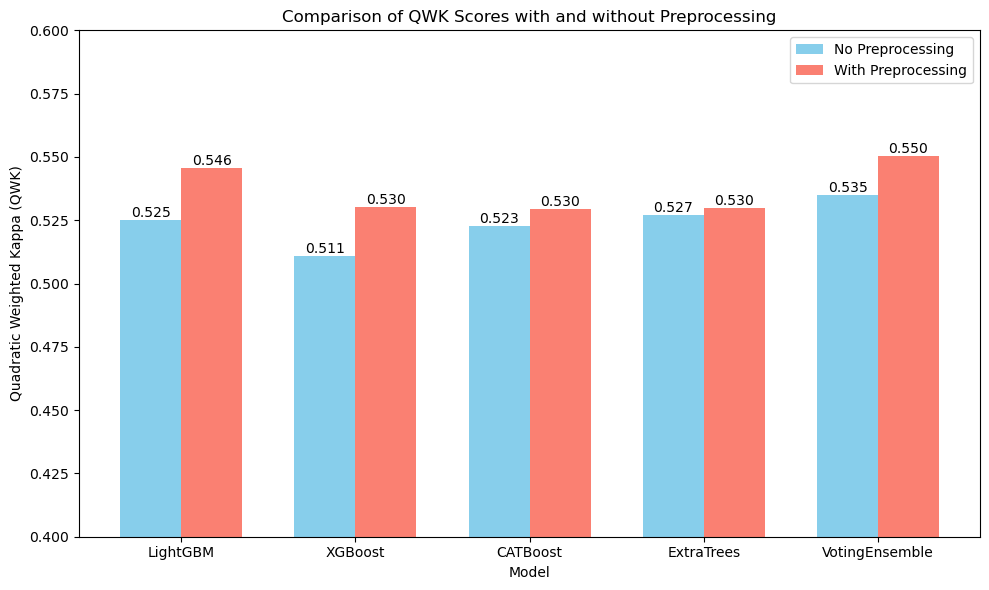

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# 모델과 QWK 점수를 정의
models = ['LightGBM', 'XGBoost', 'CATBoost', 'ExtraTrees', 'VotingEnsemble']
qwk_no_preprocess = [0.5249558004814294, 0.5108150402432732, 0.5227759393730858, 0.5271296780256454, 0.5348602950906796]
qwk_preprocess = [0.5457636086552697, 0.5301506673386238, 0.5295799145982104, 0.5298836643941957, 0.5503221750878864]

# 막대 그래프 너비 설정
bar_width = 0.35
index = np.arange(len(models))

# 막대 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 전처리 안한 데이터 막대 그래프
bars1 = ax.bar(index, qwk_no_preprocess, bar_width, label='No Preprocessing', color='skyblue')
# 전처리 한 데이터 막대 그래프
bars2 = ax.bar(index + bar_width, qwk_preprocess, bar_width, label='With Preprocessing', color='salmon')

# 각 막대 위에 점수 표시
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

# x축과 y축 레이블 설정
ax.set_xlabel('Model')
ax.set_ylabel('Quadratic Weighted Kappa (QWK)')
ax.set_title('Comparison of QWK Scores with and without Preprocessing')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(models)
ax.set_ylim(0.4,0.6)

# 범례와 레이아웃 설정
ax.legend()
plt.tight_layout()

# 그래프 표시
plt.show()

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, model_name):
    # Feature importance 추출
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        raise ValueError("Model does not have feature importance method.")
    
    # Feature importance를 데이터프레임으로 변환
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # 중요도에 따라 정렬
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # 시각화
    plt.figure(figsize=(12, 80))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

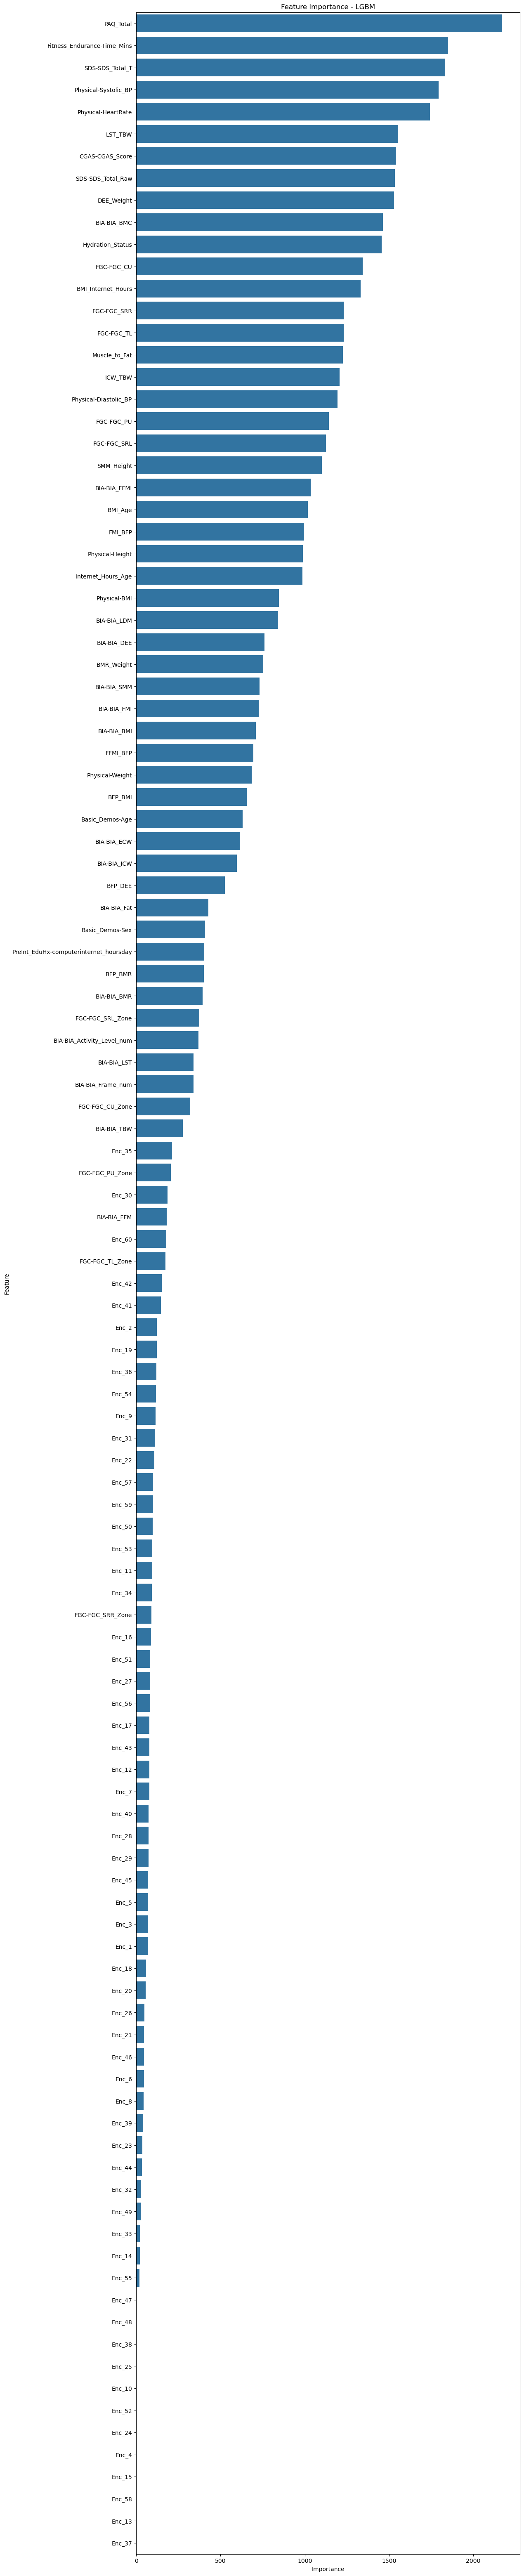

In [151]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_Light, model_trained_Light.feature_names_in_, "LGBM")

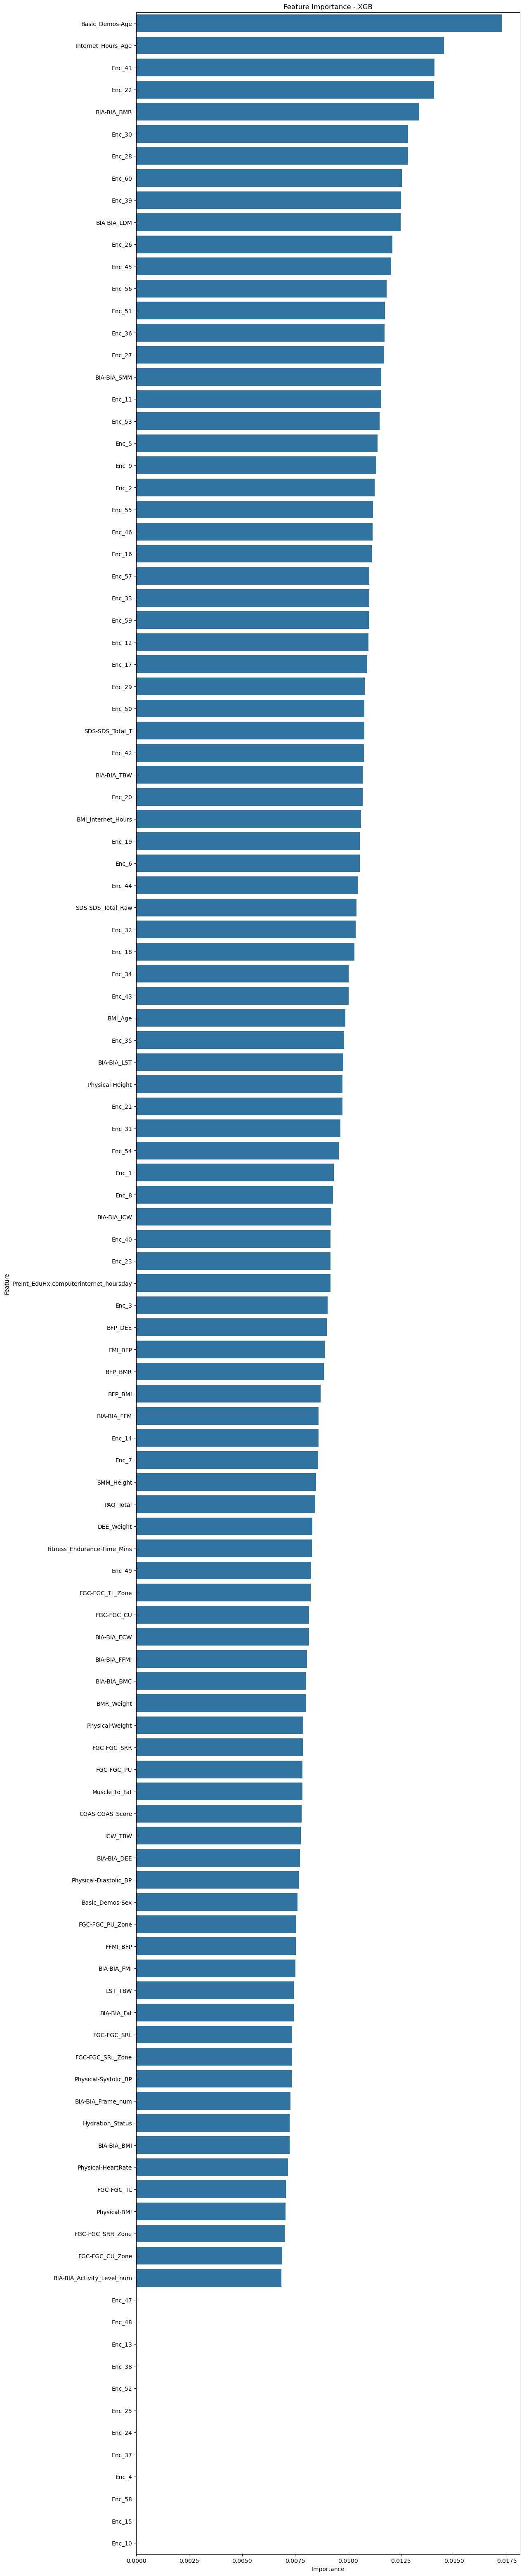

In [152]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_XGB, model_trained_XGB.feature_names_in_, "XGB")

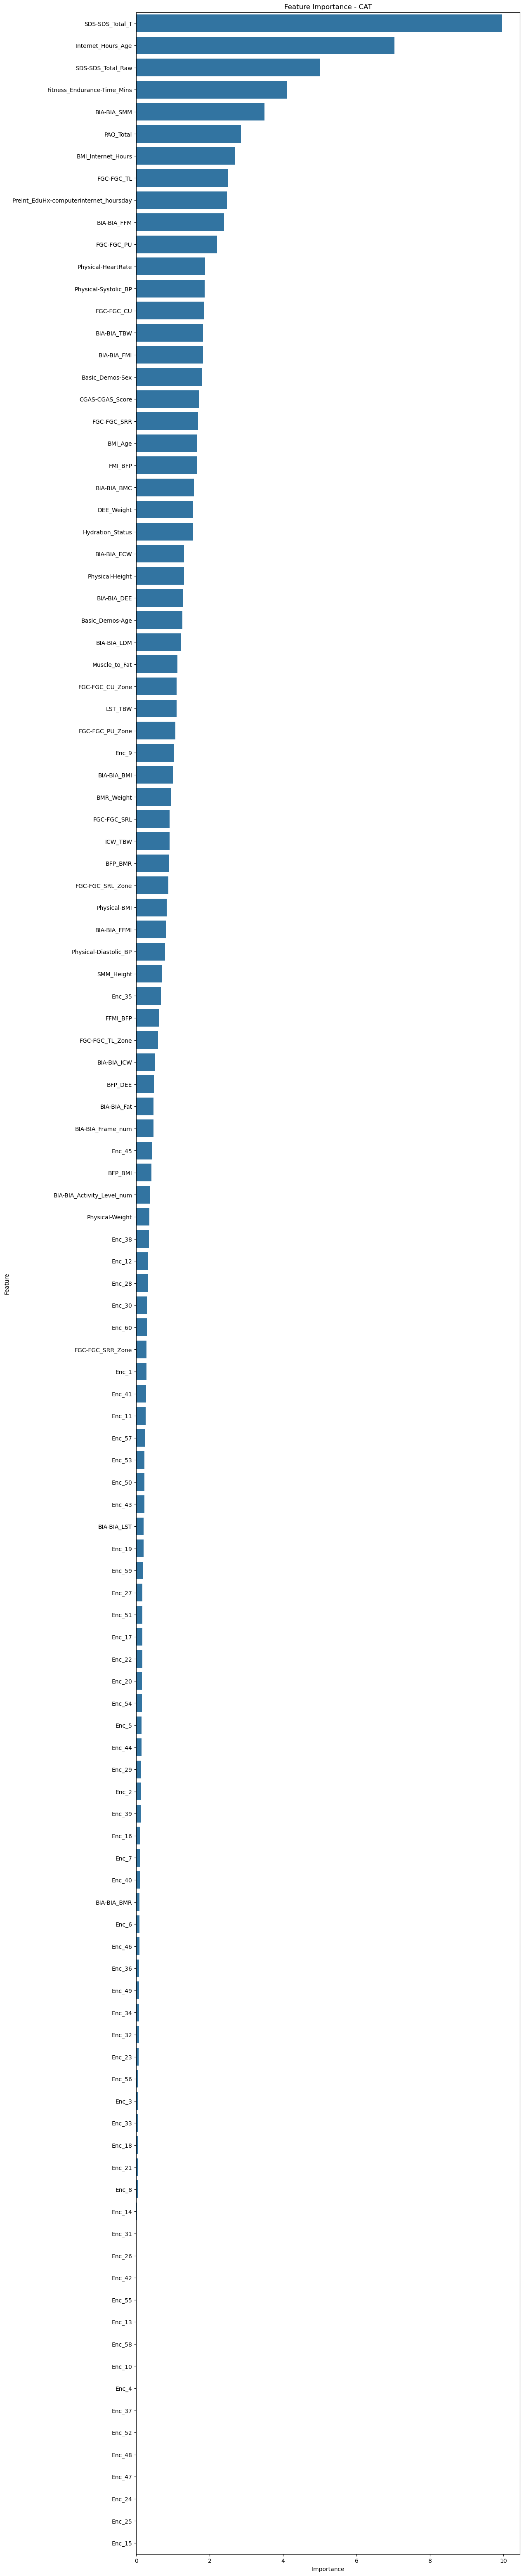

In [ ]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_Cat, model_trained_Cat.feature_names_, "CAT")

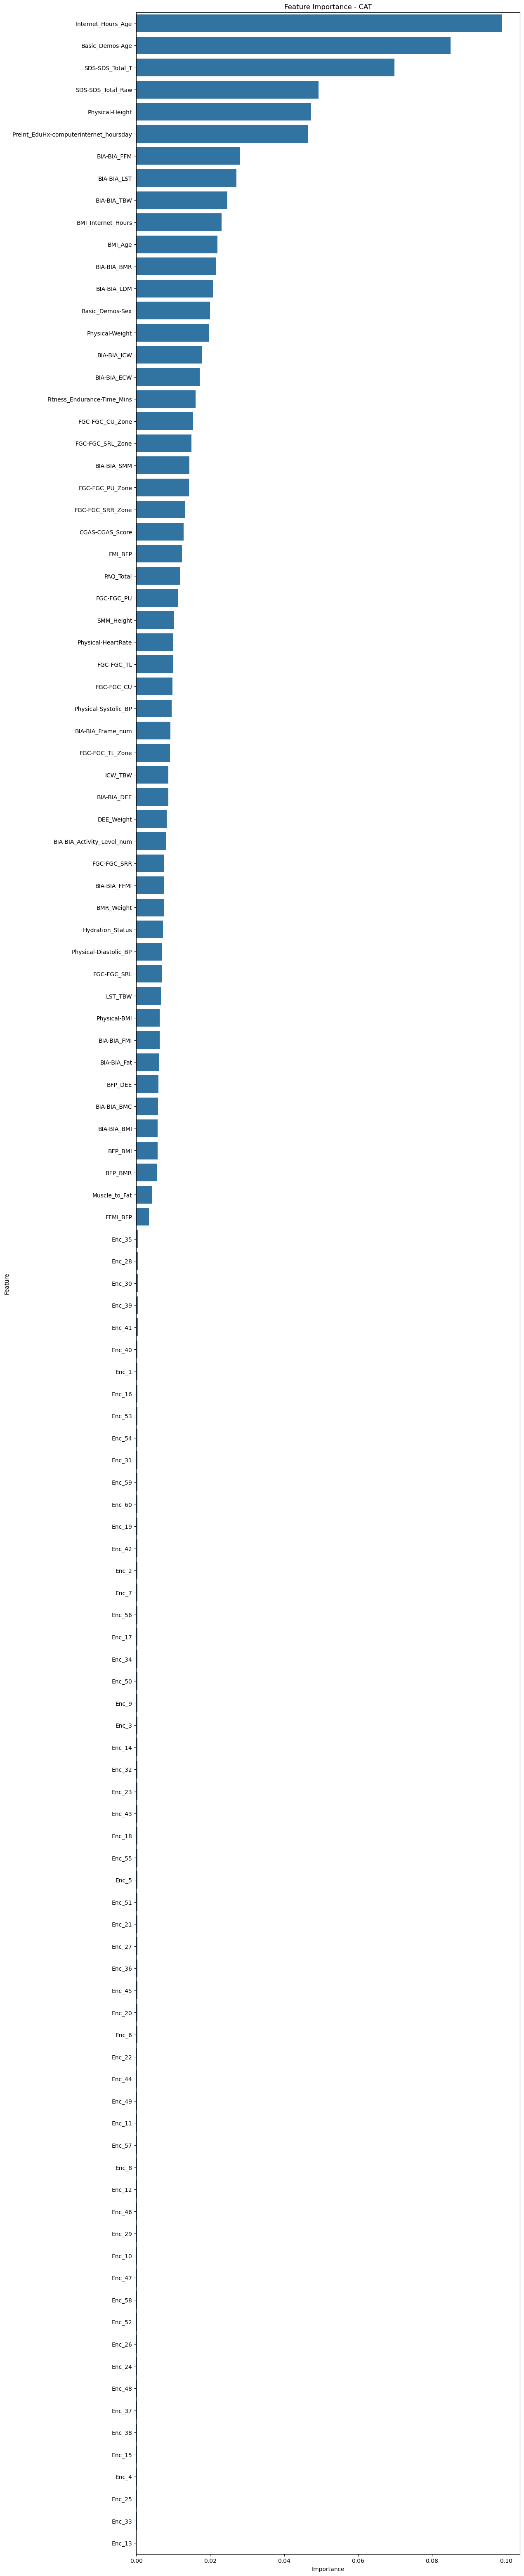

In [155]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_ET, model_trained_ET.feature_names_in_, "CAT")

# 3

- todo1    : 시계열 그냥
- 0번(캐글) : 인코딩
- 1번       : 인코딩, feature engineering  <- 이건 효훈
- 2번       : 인코딩, feature engineering, data preprocessing  <- 이 파일
- 3번       : 인코딩, feature engineering, data preprocessing, 시계열

In [1]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.metrics import cohen_kappa_score, accuracy_score, mean_squared_error
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from scipy.optimize import minimize
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# from keras.models import Model
# from keras.layers import Input, Dense
# from keras.optimizers import Adam
import torch
import torch.nn as nn
import torch.optim as optim
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.callbacks import Callback

from colorama import Fore, Style
from IPython.display import clear_output
import warnings
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

SEED = 42
n_splits = 5


def calculate_regularity_index(df):
    # timestep 설정
    start_date = pd.to_datetime('2024-01-01')
    df['timestep'] = start_date + pd.to_timedelta(df['relative_date_PCIAT'], unit='D')
    df['timestep'] += pd.to_timedelta(df['time_of_day'], unit='ns')
    df = df.set_index('timestep')

    # 시계 미착용 시점 필터링
    wear_df = df[df['non-wear_flag'] == 0.0]
    
    # 5분 간격으로 재설정
    # https://wikidocs.net/158101
    wear_df = wear_df.resample('5T').mean()

    # 모든 날짜를 하루로 겹칠 수 있도록 relative_timestep 생성 후, daily_pattern(index: 날짜, 열: relative_timestep) 생성
    wear_df['relative_timestep'] = wear_df.index.hour + wear_df.index.minute / 60
    wear_df['date_only'] = wear_df.index.date
    daily_pattern = wear_df.groupby(['date_only', 'relative_timestep'])['light'].mean().unstack()

    # 규칙성 지표 계산 : 각 시점에서의 일별 표준편차 계산 후 합산 (결측치는 자동으로 제외됨)
    std_dev_per_time_of_day = daily_pattern.std()
    regularity_index = 1/(1+std_dev_per_time_of_day.sum())
    
    """
    # 그런데, 데이터 수가 많을수록 표준편차의 신뢰도가 높아지므로...? 이를 반영...?
    # 표준편차를 데이터 수로 가중 평균하여 규칙성 지표 계산해야 할까...?
    counts_per_time_of_day = daily_pattern.count() # 각 시점별 데이터 수
    weighted_std = std_dev_per_time_of_day * counts_per_time_of_day
    regularity_index = 1 / (1 + weighted_std.sum())
    """
    
    sleep_df = wear_df[wear_df['light'] <= 2]
    # 1시간 이상 끊긴 지점을 찾기
    time_diff = sleep_df.index.to_series().diff()  # 시간 차이 계산
    gap_indices = time_diff[time_diff >= pd.Timedelta(hours=1)].index  # 1시간 이상 차이 발생한 인덱스

    # 각 묶음의 끝시간과 시작시간 차이 계산
    sleep_periods = []
    start_idx = 0

    for idx in gap_indices:
        # 현재 구간의 시작부터 gap_indices 직전까지의 차이 계산
        period = sleep_df.index[start_idx], idx
        sleep_periods.append(period)
        start_idx = sleep_df.index.get_loc(idx)  # 새로운 구간의 시작 인덱스 설정

    if len(sleep_df) > 10:
        # 마지막 구간
        period = sleep_df.index[start_idx], sleep_df.index[-1]
        sleep_periods.append(period)

        # 결과적으로 각 구간의 시간 차이 리스트
        time_differences = [(end - start).total_seconds() / 3600 for start, end in sleep_periods]

        # 수면 지속 시간의 4분위값과 표준편차 계산
        sleep_q1 = np.percentile(time_differences, 25)
        sleep_q2 = np.percentile(time_differences, 50)  # 중간값
        sleep_q3 = np.percentile(time_differences, 75)

        # 표준편차 계산
        sleep_std_dev = np.std(time_differences)

        return regularity_index, sleep_q1, sleep_q2, sleep_q3, sleep_std_dev
    else:
        return regularity_index, 0, 0, 0, 0

def process_file(filename, dirname):
    df = pd.read_parquet(os.path.join(os.getcwd(), dirname, filename, 'part-0.parquet'))
    df.drop('step', axis=1, inplace=True)

    regularity_index, sleep_q1, sleep_q2, sleep_q3, sleep_std_dev = calculate_regularity_index(df)
    df = df[['enmo', 'anglez', 'light']]
    return df.describe().values.reshape(-1), filename.split('=')[1], regularity_index, sleep_q1, sleep_q2, sleep_q3, sleep_std_dev

def load_time_series(dirname) -> pd.DataFrame:
    ids = os.listdir(dirname)
    
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(lambda fname: process_file(fname, dirname), ids), total=len(ids)))
    
    stats, indexes, regularity_indexes, sleep_q1, sleep_q2, sleep_q3, sleep_std_dev = zip(*results)
    
    df = pd.DataFrame(stats, columns=[f"stat_{i}" for i in range(len(stats[0]))])
    df['id'] = indexes
    df['regularity_index'] = regularity_indexes
    df['sleep_q1'] = sleep_q1
    df['sleep_q2'] = sleep_q2
    df['sleep_q3'] = sleep_q3
    df['sleep_std_dev'] = sleep_std_dev

    return df

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, encoding_dim*3),
            nn.ReLU(),
            nn.Linear(encoding_dim*3, encoding_dim*2),
            nn.ReLU(),
            nn.Linear(encoding_dim*2, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*3),
            nn.ReLU(),
            nn.Linear(input_dim*3, input_dim),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
def perform_autoencoder(df, encoding_dim=50, epochs=50, batch_size=32):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    
    data_tensor = torch.FloatTensor(df_scaled)
    
    input_dim = data_tensor.shape[1]
    autoencoder = AutoEncoder(input_dim, encoding_dim)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters())
    
    for epoch in range(epochs):
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i : i + batch_size]
            optimizer.zero_grad()
            reconstructed = autoencoder(batch)
            loss = criterion(reconstructed, batch)
            loss.backward()
            optimizer.step()
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}]')
                 
    with torch.no_grad():
        encoded_data = autoencoder.encoder(data_tensor).numpy()
        
    df_encoded = pd.DataFrame(encoded_data, columns=[f'Enc_{i + 1}' for i in range(encoded_data.shape[1])])
    
    return df_encoded

def data_preprocessing(df):
    PAQ_Total = []
    for i in range(len(df)):
        if pd.isnull(df.loc[i]['PAQ_A-PAQ_A_Total']):
            if pd.isnull(df.loc[i]['PAQ_C-PAQ_C_Total']):
                PAQ_Total.append(np.nan)
            else:
                PAQ_Total.append(df.loc[i]['PAQ_C-PAQ_C_Total'])
        else:
            PAQ_Total.append(df.loc[i]['PAQ_A-PAQ_A_Total'])
    df['PAQ_Total'] = PAQ_Total
    df = df.drop(['PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total'], axis =1)
    
    df = df.drop(['Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage'], axis =1 ) #no meaning + high variance column drop

    df = df.drop(['FGC-FGC_GSND','FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'], axis=1) #GSND, GSD column drop

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)

    df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].replace(999.0, 99.0)
    df['Physical-BMI'] = df['Physical-BMI'].replace(0, np.nan)
    df['Physical-Height'] = df['Physical-Height'].replace(0, np.nan)
    df['Physical-Weight'] = df['Physical-Weight'].replace(0, np.nan)
    df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].replace(0, np.nan)
    df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].replace(0, np.nan)    
    
    
    thresholds = {
        'BIA-BIA_BMC': 400,
        'BIA-BIA_BMR': 10000,
        'BIA-BIA_DEE': 9000,
        'BIA-BIA_ECW': 150,
        'BIA-BIA_FFM': 400,
        'BIA-BIA_FFMI': 100,
        'BIA-BIA_FMI': -100,
        'BIA-BIA_Fat': -1000,
        'BIA-BIA_ICW': 200,
        'BIA-BIA_LDM': 100,
        'BIA-BIA_LST': 400,
        'BIA-BIA_SMM': 300,
        'BIA-BIA_TBW': 300
    }

    for column, threshold in thresholds.items():
        condition = df[column] > threshold if threshold > 0 else df[column] < threshold
        df[column] = np.where(condition, np.nan, df[column])
    
    return df
    
def feature_engineering(df):
    season_cols = [col for col in df.columns if 'Season' in col]
    df = df.drop(season_cols, axis=1) 
    df['BMI_Age'] = df['Physical-BMI'] * df['Basic_Demos-Age']
    df['Internet_Hours_Age'] = df['PreInt_EduHx-computerinternet_hoursday'] * df['Basic_Demos-Age']
    df['BMI_Internet_Hours'] = df['Physical-BMI'] * df['PreInt_EduHx-computerinternet_hoursday']
    df['BFP_BMI'] = df['BIA-BIA_Fat'] / df['BIA-BIA_BMI']
    df['FFMI_BFP'] = df['BIA-BIA_FFMI'] / df['BIA-BIA_Fat']
    df['FMI_BFP'] = df['BIA-BIA_FMI'] / df['BIA-BIA_Fat']
    df['LST_TBW'] = df['BIA-BIA_LST'] / df['BIA-BIA_TBW']
    df['BFP_BMR'] = df['BIA-BIA_Fat'] * df['BIA-BIA_BMR']
    df['BFP_DEE'] = df['BIA-BIA_Fat'] * df['BIA-BIA_DEE']
    df['BMR_Weight'] = df['BIA-BIA_BMR'] / df['Physical-Weight']
    df['DEE_Weight'] = df['BIA-BIA_DEE'] / df['Physical-Weight']
    df['SMM_Height'] = df['BIA-BIA_SMM'] / df['Physical-Height']
    df['Muscle_to_Fat'] = df['BIA-BIA_SMM'] / df['BIA-BIA_FMI']
    df['Hydration_Status'] = df['BIA-BIA_TBW'] / df['Physical-Weight']
    df['ICW_TBW'] = df['BIA-BIA_ICW'] / df['BIA-BIA_TBW']
    
    return df

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample = pd.read_csv('data/sample_submission.csv')
# train = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/train.csv')
# test = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/test.csv')
# sample = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/sample_submission.csv')

train['Physical-Weight'] = train['Physical-Weight'].replace(0, np.nan)
test['Physical-Weight'] = test['Physical-Weight'].replace(0, np.nan)

train_ts = load_time_series("data/series_train.parquet")
test_ts = load_time_series("data/series_test.parquet")
# train_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_train.parquet")
# test_ts = load_time_series("/kaggle/input/child-mind-institute-problematic-internet-use/series_test.parquet")

df_train = train_ts.drop('id', axis=1)
df_test = test_ts.drop('id', axis=1)

train_ts_encoded = perform_autoencoder(df_train, encoding_dim=60, epochs=100, batch_size=32)
test_ts_encoded = perform_autoencoder(df_test, encoding_dim=60, epochs=100, batch_size=32)

time_series_cols = train_ts_encoded.columns.tolist() + ['regularity_index',	'sleep_q1',	'sleep_q2',	'sleep_q3',	'sleep_std_dev']
train_ts_encoded["id"]=train_ts["id"]
test_ts_encoded['id']=test_ts["id"]

df_train = df_train[['regularity_index',	'sleep_q1',	'sleep_q2',	'sleep_q3',	'sleep_std_dev']]
df_test = df_test[['regularity_index',	'sleep_q1',	'sleep_q2',	'sleep_q3',	'sleep_std_dev']]
df_train["id"]=train_ts["id"]
df_test['id']=test_ts["id"]

train = pd.merge(train, train_ts_encoded, how="left", on='id')
train = pd.merge(train, df_train, how="left", on='id')
test = pd.merge(test, test_ts_encoded, how="left", on='id')
test = pd.merge(test, df_test, how="left", on='id')

kid_perfect = train[train['PCIAT-PCIAT_Total']==0]
no_perfect = kid_perfect[kid_perfect['PreInt_EduHx-computerinternet_hoursday']>2].index.tolist()

train = train.drop(index= no_perfect)
train = train.reset_index(drop=True)

c:\Users\USER\anaconda3\envs\kaggle\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 2/2 [00:00<00:00,  3.24it/s]


Epoch [10/100], Loss: 0.6447]
Epoch [20/100], Loss: 0.6364]
Epoch [30/100], Loss: 0.6259]
Epoch [40/100], Loss: 0.6266]
Epoch [50/100], Loss: 0.6241]
Epoch [60/100], Loss: 0.6244]
Epoch [70/100], Loss: 0.6248]
Epoch [80/100], Loss: 0.6238]
Epoch [90/100], Loss: 0.6235]
Epoch [100/100], Loss: 0.6236]
Epoch [10/100], Loss: 1.1595]
Epoch [20/100], Loss: 1.0415]
Epoch [30/100], Loss: 0.6756]
Epoch [40/100], Loss: 0.4883]
Epoch [50/100], Loss: 0.4656]
Epoch [60/100], Loss: 0.4655]
Epoch [70/100], Loss: 0.4655]
Epoch [80/100], Loss: 0.4655]
Epoch [90/100], Loss: 0.4655]
Epoch [100/100], Loss: 0.4655]


In [2]:
train = data_preprocessing(train)
test = data_preprocessing(test)

In [3]:
imputer = KNNImputer(n_neighbors=5)
numeric_cols = train.select_dtypes(include=['int32', 'int64', 'float64', 'int64']).columns
imputed_data = imputer.fit_transform(train[numeric_cols])
train_imputed = pd.DataFrame(imputed_data, columns=numeric_cols)
train_imputed['sii'] = train_imputed['sii'].round().astype(int)
for col in train.columns:
    if col not in numeric_cols:
        train_imputed[col] = train[col]
        
train = train_imputed

train = feature_engineering(train)
train = train.dropna(thresh=10, axis=0)
test = feature_engineering(test)

In [4]:
train.drop('id', axis=1)
train

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Time_Mins,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,regularity_index,sleep_q1,sleep_q2,sleep_q3,sleep_std_dev,PAQ_Total,id,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,5.0,0.0,51.0,16.877316,46.00,50.80,61.2,86.4,110.6,5.8,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.668550,16.87920,932.4980,1492.000,8.255980,41.58620,13.81770,3.061430,9.213770,1.0,24.43490,8.895360,38.91770,19.54130,32.69090,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,48.4,62.2,3.0,2,0.000068,2.887500,5.725000,11.720833,8.658046,2.222,00008ff9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,9.0,0.0,71.0,14.035590,48.00,46.00,75.0,70.0,122.0,6.6,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.579490,14.03710,936.6560,1498.650,6.019930,42.02910,12.82540,1.211720,3.970850,1.0,21.03520,14.974000,39.44970,15.41070,27.05520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0,0.000105,2.970833,6.183333,12.887500,16.735657,2.340,000fd460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,10.0,1.0,71.0,16.648696,56.50,75.60,65.0,94.0,117.0,7.0,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,2.6,3.428146,19.09980,1105.3782,1887.522,17.112254,60.00024,14.86322,4.236552,17.519748,2.6,28.95074,13.937256,56.57208,28.11530,46.06298,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0,0.000122,4.687500,9.633333,19.325000,48.356092,2.170,00105258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.486961,20.0,33.297392,0.917274,0.848370,0.241816,1.228146,19365.947509,33068.909784,14.621405,24.967222,0.497616,6.636364,0.609299,0.628503
3,9.0,0.0,71.0,18.292347,56.00,81.60,60.0,97.0,117.0,9.0,18.0,1.0,5.0,0.0,7.0,0.0

In [5]:
test.drop('id', axis=1)
test

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Time_Mins,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Enc_1,Enc_2,Enc_3,Enc_4,Enc_5,Enc_6,Enc_7,Enc_8,Enc_9,Enc_10,Enc_11,Enc_12,Enc_13,Enc_14,Enc_15,Enc_16,Enc_17,Enc_18,Enc_19,Enc_20,Enc_21,Enc_22,Enc_23,Enc_24,Enc_25,Enc_26,Enc_27,Enc_28,Enc_29,Enc_30,Enc_31,Enc_32,Enc_33,Enc_34,Enc_35,Enc_36,Enc_37,Enc_38,Enc_39,Enc_40,Enc_41,Enc_42,Enc_43,Enc_44,Enc_45,Enc_46,Enc_47,Enc_48,Enc_49,Enc_50,Enc_51,Enc_52,Enc_53,Enc_54,Enc_55,Enc_56,Enc_57,Enc_58,Enc_59,Enc_60,regularity_index,sleep_q1,sleep_q2,sleep_q3,sleep_std_dev,PAQ_Total,BMI_Age,Internet_Hours_Age,BMI_Internet_Hours,BFP_BMI,FFMI_BFP,FMI_BFP,LST_TBW,BFP_BMR,BFP_DEE,BMR_Weight,DEE_Weight,SMM_Height,Muscle_to_Fat,Hydration_Status,ICW_TBW
0,00008ff9,5,0,51.0,16.877316,46.00,50.8,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.386578,15.0,50.631947,0.545865,1.499679,0.332267,1.190475,8591.822097,13746.944840,18.356260,29.370079,0.424811,6.383063,0.643522,0.747453
1,000fd460,9,0,NaN,14.035590,48.00,46.0,75.0,70.0,122.0,NaN,3.0,0.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,46.0,64.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.340,126.320313,0.0,0.000000,0.282883,3.229888,0.305154,1.458119,3719.320478,5950.914352,20.362087,32.579348,0.321056,12.718037,0.588157,0.777492
2,00105258,10,1,71.0,16.648696,56.50,75.6,65.0,94.0,117.0,7.0,20.0,1.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,54.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.170,166.486961,20.0,33.297392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,9,0,71.0,18.292347,56.00,81.6,60.0,97.0,117.0,9.0,18.0,1.0,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,31.0,45.0,0.0,0.0,0.0,0.000000,0.0,0.0,13.242002,0.000000,0.0,11.395288,0.0,0.0,0.0,0.0,14.121736,15.426091,0.000000,0.0,11.85326,20.685722,0.0,13.353408,0.0,0.0,0.0,4.257409,15.333481,0.000000,0.0,0.0,0.0,0.0,10.671705,0.000000,0.0,0.0,8.660523,0.000000,14.800072,21.57346,0.0,1.033049,0.000000,0.0,13.956299,16.576605,10.93818,7.848758,14.857033,0.0,0.0,0.0,6.476468,13.500938,0.071086,0.393072,13.467978,0.0,13.987114,0.0,0.0,0.000044,2.208333,4.333333,18.375,69.354798,2.451,164.631122,0.0,0.000000,1.028971,0.747651,0.224196,1.281264,21298.377749,36207.411592,13.865564,23.571569,0.472854,6.274343,0.563684,0.661008
4,0016bb22,18,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Time_Mins', 
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'sii', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

## 제외 목록
#'Physical-Waist_Circumference','Fitness_Endurance-Time_Sec','Fitness_Endurance-Max_Stage',
#'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone'

featuresCols += time_series_cols

train = train[featuresCols]
train = train.dropna(subset='sii')

featuresCols = ['Basic_Demos-Age', 'Basic_Demos-Sex',
                'CGAS-CGAS_Score', 'Physical-BMI',
                'Physical-Height', 'Physical-Weight', 
                'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
                'Fitness_Endurance-Time_Mins', 
                'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
                'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
                'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
                'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
                'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
                'BIA-BIA_TBW', 'PAQ_Total', 'SDS-SDS_Total_Raw',
                'SDS-SDS_Total_T',
                'PreInt_EduHx-computerinternet_hoursday', 'BMI_Age','Internet_Hours_Age','BMI_Internet_Hours',
                'BFP_BMI', 'FFMI_BFP', 'FMI_BFP', 'LST_TBW', 'BFP_BMR', 'BFP_DEE', 'BMR_Weight', 'DEE_Weight',
                'SMM_Height', 'Muscle_to_Fat', 'Hydration_Status', 'ICW_TBW']

featuresCols += time_series_cols
test = test[featuresCols]
if np.any(np.isinf(train)):
    train = train.replace([np.inf, -np.inf], np.nan)

In [7]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true.round(0).astype(int), y_pred.round(0).astype(int), weights='quadratic')

def threshold_Rounder(oof_non_rounded, thresholds):
    return np.where(oof_non_rounded < thresholds[0], 0,
                    np.where(oof_non_rounded < thresholds[1], 1,
                             np.where(oof_non_rounded < thresholds[2], 2, 3)))

def evaluate_predictions(thresholds, y_true, oof_non_rounded):
    rounded_p = threshold_Rounder(oof_non_rounded, thresholds)
    return -quadratic_weighted_kappa(y_true, rounded_p)

def TrainML(model_class, test_data):
    X = train.drop(['sii'], axis=1)
    y = train['sii']

    SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    train_S = []
    test_S = []
    
    oof_non_rounded = np.zeros(len(y), dtype=float) 
    oof_rounded = np.zeros(len(y), dtype=int) 
    test_preds = np.zeros((len(test_data), n_splits))

    #for fold, (train_idx, test_idx) in enumerate(tqdm(SKF.split(X, y), desc="Training Folds", total=n_splits)):
    for fold, (train_idx, test_idx) in enumerate(SKF.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model = clone(model_class)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        oof_non_rounded[test_idx] = y_val_pred
        y_val_pred_rounded = y_val_pred.round(0).astype(int)
        oof_rounded[test_idx] = y_val_pred_rounded

        train_kappa = quadratic_weighted_kappa(y_train, y_train_pred.round(0).astype(int))
        val_kappa = quadratic_weighted_kappa(y_val, y_val_pred_rounded)

        train_S.append(train_kappa)
        test_S.append(val_kappa)
        
        test_preds[:, fold] = model.predict(test_data)
        
        #print(f"Fold {fold+1} - Train QWK: {train_kappa:.4f}, Validation QWK: {val_kappa:.4f}")
        #clear_output(wait=True)

    #print(f"Mean Train QWK --> {np.mean(train_S):.4f}")
    #print(f"Mean Validation QWK ---> {np.mean(test_S):.4f}")

    KappaOPtimizer = minimize(evaluate_predictions,
                              x0=[0.5, 1.5, 2.5], args=(y, oof_non_rounded), 
                              method='Nelder-Mead')
    assert KappaOPtimizer.success, "Optimization did not converge."
    
    oof_tuned = threshold_Rounder(oof_non_rounded, KappaOPtimizer.x)
    tKappa = quadratic_weighted_kappa(y, oof_tuned)

    #print(f"----> || Optimized QWK SCORE :: {Fore.CYAN}{Style.BRIGHT} {tKappa:.3f}{Style.RESET_ALL}")

    tpm = test_preds.mean(axis=1)
    tpTuned = threshold_Rounder(tpm, KappaOPtimizer.x)
    
    submission = pd.DataFrame({
        'id': sample['id'],
        'sii': tpTuned
    })

    return submission, tKappa, model

from sklearn.metrics import cohen_kappa_score
from pytorch_tabnet.metrics import Metric

# def quadratic_weighted_kappa(y_true, y_pred):
    
#     threshold_ = [0.5, 1.5, 2.5]
#     y_pred = np.where(y_pred < threshold_[0], 0,
#                         np.where(y_pred < threshold_[1], 1,
#                                 np.where(y_pred < threshold_[2], 2, 3)))
    
#     return cohen_kappa_score(y_true, y_pred, weights="quadratic")

class QuadraticWeightedKappaMetric(Metric):
    def __init__(self):
        self._name = "qwk"
        self._maximize = True

    def __call__(self, y_true, y_pred):
        return quadratic_weighted_kappa(y_true, y_pred.round(0).astype(int))

class TabNetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, **kwargs):
        self.model = TabNetRegressor(**kwargs)
        self.kwargs = kwargs
        self.imputer = SimpleImputer(strategy='median')
        self.best_model_path = 'best_tab_model.pt'
        
    def fit(self, X, y):
        X_imputed = self.imputer.fit_transform(X)
            
        if hasattr(y, 'values'):
            y = y.values

        X_train, X_valid, y_train, y_valid = train_test_split(X_imputed, y, test_size=0.2, random_state=SEED)

        history = self.model.fit(
            X_train=X_train,
            y_train=y_train.reshape(-1, 1),
            eval_set=[(X_valid, y_valid.reshape(-1, 1))],
            eval_name=['valid'],
            eval_metric=[QuadraticWeightedKappaMetric],
            max_epochs=500,
            patience=50,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=16,
            drop_last=False,
            callbacks=[
                TabNetPretrainedModelCheckpoint(
                    filepath=self.best_model_path,
                    monitor='valid_qwk',
                    save_best_only=True,
                    verbose=1
                )
            ]
        )

        if os.path.exists(self.best_model_path):
            self.model.load_model(self.best_model_path)
            os.remove(self.best_model_path)

        return self

    def predict(self, X):
        X_imputed = self.imputer.transform(X)
        return self.model.predict(X_imputed).flatten()

    def __deepcopy__(self, memo):
        cls = self.__class__
        result = self.__new__(cls)
        memo[id(self)] = result
        for k, v in self.__dict__.items():
            setattr(result, k, deepcopy(v, memo))

        return result

class TabNetPretrainedModelCheckpoint(Callback):
    def __init__(self, filepath, monitor='val_loss', mode='max', save_best_only=True, verbose=1):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.verbose = verbose
        self.best = float('inf') if mode == 'min' else -float('inf')
        
    def on_train_begin(self, logs=None):
        self.model = self.trainer
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        
        if (self.mode == 'min' and current < self.best) or (self.mode == 'max' and current > self.best):
            if self.verbose:
                print(f'\nEpoch {epoch}: {self.monitor} improved from {self.best:.4f} to {current:.4f}')
            self.best = current
            if self.save_best_only:
                self.model.save_model(self.filepath)

In [ ]:
SEED = 42

def objective_lgbm(trial):
    param = {
        'num_leaves': trial.suggest_int('num_leaves', 300, 2000, 50),
        'max_depth': trial.suggest_int('max_depth', 8, 32), 
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1), 
        'n_estimators': trial.suggest_int('n_estimators', 800, 2000, 10), 
        #'min_child_samples': trial.suggest_int('min_child_samples', 30, 100),  
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50, 5),  
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0), 
        #'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0), 
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 0.1, 20.0), 
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.5, 1.0),  
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.5, 1.0), 
        #'min_gain_to_split': trial.suggest_loguniform('min_gain_to_split', 1e-8, 1.0),  
        'random_state': SEED,
    }

    submission, qwk_score, _ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_lgbm = optuna.create_study(direction='maximize', sampler=sampler)
study_lgbm.optimize(objective_lgbm, n_trials=100)

print("Best LGBM params: ", study_lgbm.best_params)
print("Best LGBM score: ", study_lgbm.best_value)

[I 2024-10-31 13:46:11,736] A new study created in memory with name: no-name-5c82de1f-5444-4b97-a82d-f0918ceb3160
[I 2024-10-31 13:46:54,699] Trial 0 finished with value: 0.47232667878053836 and parameters: {'num_leaves': 950, 'max_depth': 31, 'learning_rate': 0.015702970884055395, 'n_estimators': 1520, 'min_data_in_leaf': 10, 'subsample': 0.5779972601681014, 'reg_alpha': 0.1360354613611808, 'reg_lambda': 0.08499808989182997, 'feature_fraction': 0.8005575058716043, 'bagging_fraction': 0.8540362888980227}. Best is trial 0 with value: 0.47232667878053836.
[I 2024-10-31 13:47:09,308] Trial 1 finished with value: 0.5011494190260577 and parameters: {'num_leaves': 300, 'max_depth': 32, 'learning_rate': 0.03142880890840111, 'n_estimators': 1050, 'min_data_in_leaf': 10, 'subsample': 0.5917022549267169, 'reg_alpha': 0.5012686302434877, 'reg_lambda': 0.00015777981883364995, 'feature_fraction': 0.7159725093210578, 'bagging_fraction': 0.645614570099021}. Best is trial 1 with value: 0.5011494190260

Best LGBM params:  {'num_leaves': 1650, 'max_depth': 22, 'learning_rate': 0.005541066940882869, 'n_estimators': 990, 'min_data_in_leaf': 25, 'subsample': 0.9714074143029313, 'reg_alpha': 5.8052925063378895, 'reg_lambda': 0.0019424516227001005, 'feature_fraction': 0.601085058149202, 'bagging_fraction': 0.7897436123823176}
Best LGBM score:  0.5332874673746577


In [ ]:
# https://docs.getml.com/1.1.0/api/getml.predictors.XGBoostRegressor.html

def objective_xgb(trial):

    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1e-1),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-4, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'random_state': SEED,
        #'device': 'cuda'
    }

    submission, qwk_score,_ = TrainML(LGBMRegressor(**param, n_jobs=-1, verbose = -1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=100)

print("Best XGB params: ", study_xgb.best_params)
print("Best XGB score: ", study_xgb.best_value)

[I 2024-10-31 14:57:29,400] A new study created in memory with name: no-name-bd5b46ed-218f-4390-9a58-ff32f7c31a85
[I 2024-10-31 14:58:16,913] Trial 0 finished with value: 0.51428986045107 and parameters: {'max_depth': 13, 'n_estimators': 1920, 'learning_rate': 0.015702970884055395, 'reg_alpha': 0.09846738873614563, 'reg_lambda': 0.00042079886696066364, 'colsample_bylevel': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'min_child_weight': 8.795585311974417, 'subsample': 0.6410035105688879}. Best is trial 0 with value: 0.51428986045107.
[I 2024-10-31 14:58:25,598] Trial 1 finished with value: 0.5022674908558014 and parameters: {'max_depth': 22, 'n_estimators': 330, 'learning_rate': 0.0812324508558869, 'reg_alpha': 1.452824663751602, 'reg_lambda': 0.0007068974950624604, 'colsample_bylevel': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'min_child_weight': 3.7381801866358395, 'subsample': 0.5722807884690141}. Best is trial 0 with value: 0.51428986045107.
[I 2024

Best XGB params:  {'max_depth': 15, 'n_estimators': 930, 'learning_rate': 0.008106438245091278, 'reg_alpha': 0.019442145957845332, 'reg_lambda': 0.41254042032294636, 'colsample_bylevel': 0.7767717096445044, 'colsample_bytree': 0.6857030408686234, 'min_child_weight': 9.10947009522796, 'subsample': 0.19323524528985037}
Best XGB score:  0.5328229267955094


In [ ]:
# https://catboost.ai/en/docs/concepts/python-reference_catboostregressor

def objective_cat(trial):

    param = {
        'iterations':trial.suggest_int("iterations", 100, 500, 50),
        #'od_wait':trial.suggest_int('od_wait', 500, 2300, 50),
        'learning_rate' : trial.suggest_uniform('learning_rate',1e-4, 1),
        'reg_lambda': trial.suggest_uniform('reg_lambda',1e-5,100),
        #'subsample': trial.suggest_uniform('subsample',0,1),
        #'random_strength': trial.suggest_uniform('random_strength',10,50),
        'depth': trial.suggest_int('depth',1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf',1,30),
        #'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations',1,15),
        #'bagging_temperature' :trial.suggest_loguniform('bagging_temperature', 0.01, 100.00),
        #'colsample_bylevel':trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'random_state': SEED,
        #'task_type': 'GPU'
    }

    submission, qwk_score,_ = TrainML(CatBoostRegressor(**param,verbose=0), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_cat = optuna.create_study(direction='maximize', sampler=sampler)
study_cat.optimize(objective_cat, n_trials=100)

print("Best CAT params: ", study_cat.best_params)
print("Best CAT score: ", study_cat.best_value)

[I 2024-10-31 15:19:11,155] A new study created in memory with name: no-name-f7015058-6e2c-4d26-8d80-1da990f5c116
[I 2024-10-31 15:19:16,969] Trial 0 finished with value: 0.48311637545665376 and parameters: {'iterations': 250, 'learning_rate': 0.9507192349792751, 'reg_lambda': 73.1993968612011, 'depth': 6, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.48311637545665376.
[I 2024-10-31 15:19:22,903] Trial 1 finished with value: 0.49267791188480603 and parameters: {'iterations': 150, 'learning_rate': 0.05817780380698265, 'reg_lambda': 86.61761591573206, 'depth': 7, 'min_data_in_leaf': 22}. Best is trial 1 with value: 0.49267791188480603.
[I 2024-10-31 15:19:23,873] Trial 2 finished with value: 0.497031095929545 and parameters: {'iterations': 100, 'learning_rate': 0.9699128611767781, 'reg_lambda': 83.24426575561577, 'depth': 3, 'min_data_in_leaf': 6}. Best is trial 2 with value: 0.497031095929545.
[I 2024-10-31 15:19:26,153] Trial 3 finished with value: 0.5187036028368832 and param

In [ ]:
# https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

from sklearn.ensemble import ExtraTreesRegressor

train = train.fillna(-999)
test = test.fillna(-999)

def objective_et(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, 10),
        #'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state': SEED
    }
    
    submission, qwk_score,_ = TrainML(ExtraTreesRegressor(**param, n_jobs=-1), test)
    
    return qwk_score

sampler = TPESampler(seed=42)
study_et = optuna.create_study(direction='maximize', sampler=sampler)
study_et.optimize(objective_et, n_trials=100)

print("Best ET params: ", study_et.best_params)
print("Best ET score: ", study_et.best_value)

In [9]:
from sklearn.ensemble import ExtraTreesRegressor

LGBM_Params = {'num_leaves': 1650, 'max_depth': 22, 'learning_rate': 0.005541066940882869, 'n_estimators': 990, 'min_data_in_leaf': 25, 'subsample': 0.9714074143029313, 'reg_alpha': 5.8052925063378895, 'reg_lambda': 0.0019424516227001005, 'feature_fraction': 0.601085058149202, 'bagging_fraction': 0.7897436123823176}
#Best LGBM score:  0.5332874673746577

XGB_Params = {'max_depth': 15, 'n_estimators': 930, 'learning_rate': 0.008106438245091278, 'reg_alpha': 0.019442145957845332, 'reg_lambda': 0.41254042032294636, 'colsample_bylevel': 0.7767717096445044, 'colsample_bytree': 0.6857030408686234, 'min_child_weight': 9.10947009522796, 'subsample': 0.19323524528985037}
#Best XGB score:  0.5328229267955094

CatBoost_Params = {'iterations': 200, 'learning_rate': 0.2799393672399636, 'reg_lambda': 85.43359398477288, 'depth': 8, 'min_data_in_leaf': 28}
#Best CAT score:  0.5264957508725612

ET_Params = {'n_estimators': 990, 'min_samples_split': 2, 'min_samples_leaf': 7}
#Best ET score:  0.5275742366912608

TabNet_Params = {
    'n_d': 64,              # Width of the decision prediction layer
    'n_a': 64,              # Width of the attention embedding for each step
    'n_steps': 5,           # Number of steps in the architecture
    'gamma': 1.5,           # Coefficient for feature selection regularization
    'n_independent': 2,     # Number of independent GLU layer in each GLU block
    'n_shared': 2,          # Number of shared GLU layer in each GLU block
    'lambda_sparse': 1e-4,  # Sparsity regularization
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2, weight_decay=1e-5),
    'mask_type': 'entmax',
    'scheduler_params': dict(mode="min", patience=10, min_lr=1e-5, factor=0.5),
    'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    'verbose': 1,
    'device_name': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create model instances
Light = LGBMRegressor(**LGBM_Params, random_state=SEED, verbose=-1)
XGB_Model = XGBRegressor(**XGB_Params, random_state=SEED)
CatBoost_Model = CatBoostRegressor(**CatBoost_Params, random_state=SEED, verbose=0)
ET_Model = ExtraTreesRegressor(**ET_Params, random_state=SEED)
TabNet_Model = TabNetWrapper(**TabNet_Params)

In [10]:
Submission_Light, qwk_score_Light, model_trained_Light = TrainML(Light, test)
qwk_score_Light

0.5549430876339927

In [11]:
Submission_XGB, qwk_score_XGB, model_trained_XGB = TrainML(XGB_Model, test)
qwk_score_XGB

0.5656094446545157

In [12]:
Submission_Cat, qwk_score_Cat, model_trained_Cat = TrainML(CatBoost_Model, test)
qwk_score_Cat

0.5470852904731297

In [13]:
Submission_TabNet, qwk_score_TabNet, model_trained_TabNet = TrainML(TabNet_Model, test)
qwk_score_TabNet

epoch 0  | loss: 1.49605 | valid_qwk: -0.0124 |  0:01:07s

Epoch 0: valid_qwk improved from -inf to -0.0124
Successfully saved model at best_tab_model.pt.zip


KeyboardInterrupt: 

In [ ]:
# extratree는 결측치를 자동으로 처리 안함
train = train.fillna(-999)
test = test.fillna(-999)

Submission_ET, qwk_score_ET, model_trained_ET = TrainML(ET_Model, test)
qwk_score_ET

0.5271296780256454

In [ ]:
Submission_Light = Submission_Light.rename(columns={'sii': 'sii_Light'})
Submission_XGB = Submission_XGB.rename(columns={'sii': 'sii_XGB'})
Submission_CatBoost = Submission_Cat.rename(columns={'sii': 'sii_CatBoost'})
Submission_ET = Submission_ET.rename(columns={'sii': 'sii_ET'})
Submission_TabNet = Submission_TabNet.rename(columns={'sii': 'sii_TabNet'})

merged_df = Submission_Light.merge(Submission_XGB, on='id') \
                            .merge(Submission_CatBoost, on='id') \
                            .merge(Submission_ET, on='id') \
                            .merge(Submission_TabNet, on='id')

merged_df

,id,sii_Light,sii_XGB,sii_CatBoost,sii_ET,sii_TabNet
0,00008ff9,0,1,1,0,3
1,000fd460,0,0,0,0,2
2,105258,1,1,1,1,3
3,00115b9f,0,0,0,0,0
4,0016bb22,0,0,0,0,3
5,001f3379,1,1,1,1,1
6,0038ba98,1,1,1,1,0
7,0068a485,0,0,0,0,3
8,0069fbed,0,1,1,0,3
9,0083e397,0,0,0,0,3


In [ ]:
# Combine models using Voting Regressor
voting_model = VotingRegressor(estimators=[
    ('lightgbm', model_trained_Light),
    ('xgboost', model_trained_XGB),
    ('catboost', model_trained_Cat),
    #('tabnet', model_trained_TabNet),
    ('et', model_trained_ET),
], )

In [ ]:
Submission, qwk_score, model_trained = TrainML(voting_model, test)

Submission.to_csv('submission.csv', index=False)
Submission

,id,sii
0,00008ff9,1
1,000fd460,0
2,105258,1
3,00115b9f,0
4,0016bb22,0
5,001f3379,1
6,0038ba98,1
7,0068a485,0
8,0069fbed,1
9,0083e397,0


In [ ]:
qwk_score

0.5348602950906796

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, model_name):
    # Feature importance 추출
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        raise ValueError("Model does not have feature importance method.")
    
    # Feature importance를 데이터프레임으로 변환
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # 중요도에 따라 정렬
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # 시각화
    plt.figure(figsize=(12, 80))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

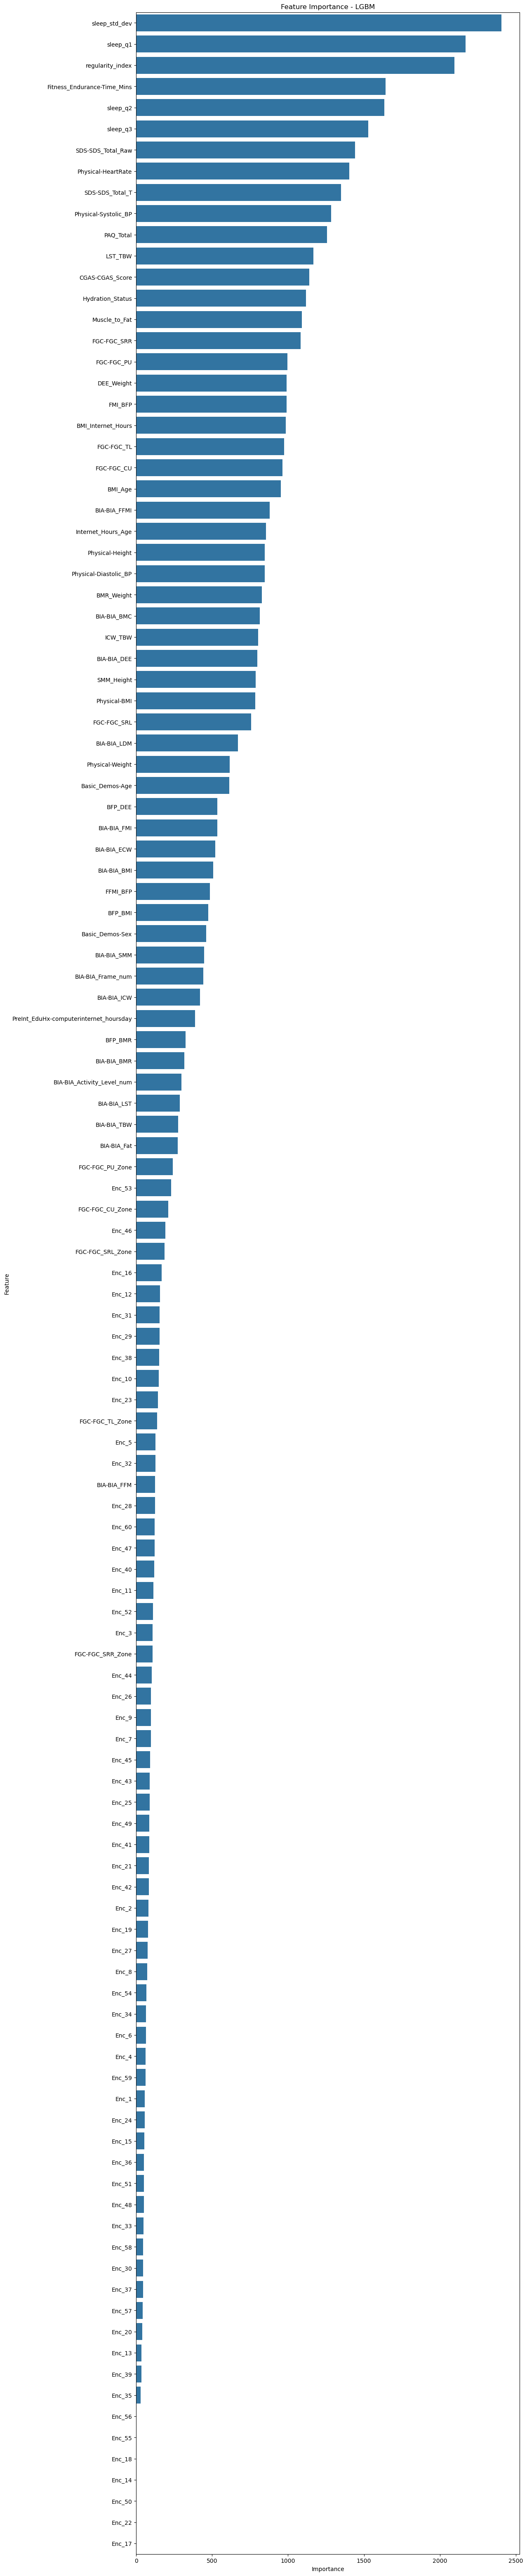

In [15]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_Light, model_trained_Light.feature_names_in_, "LGBM")

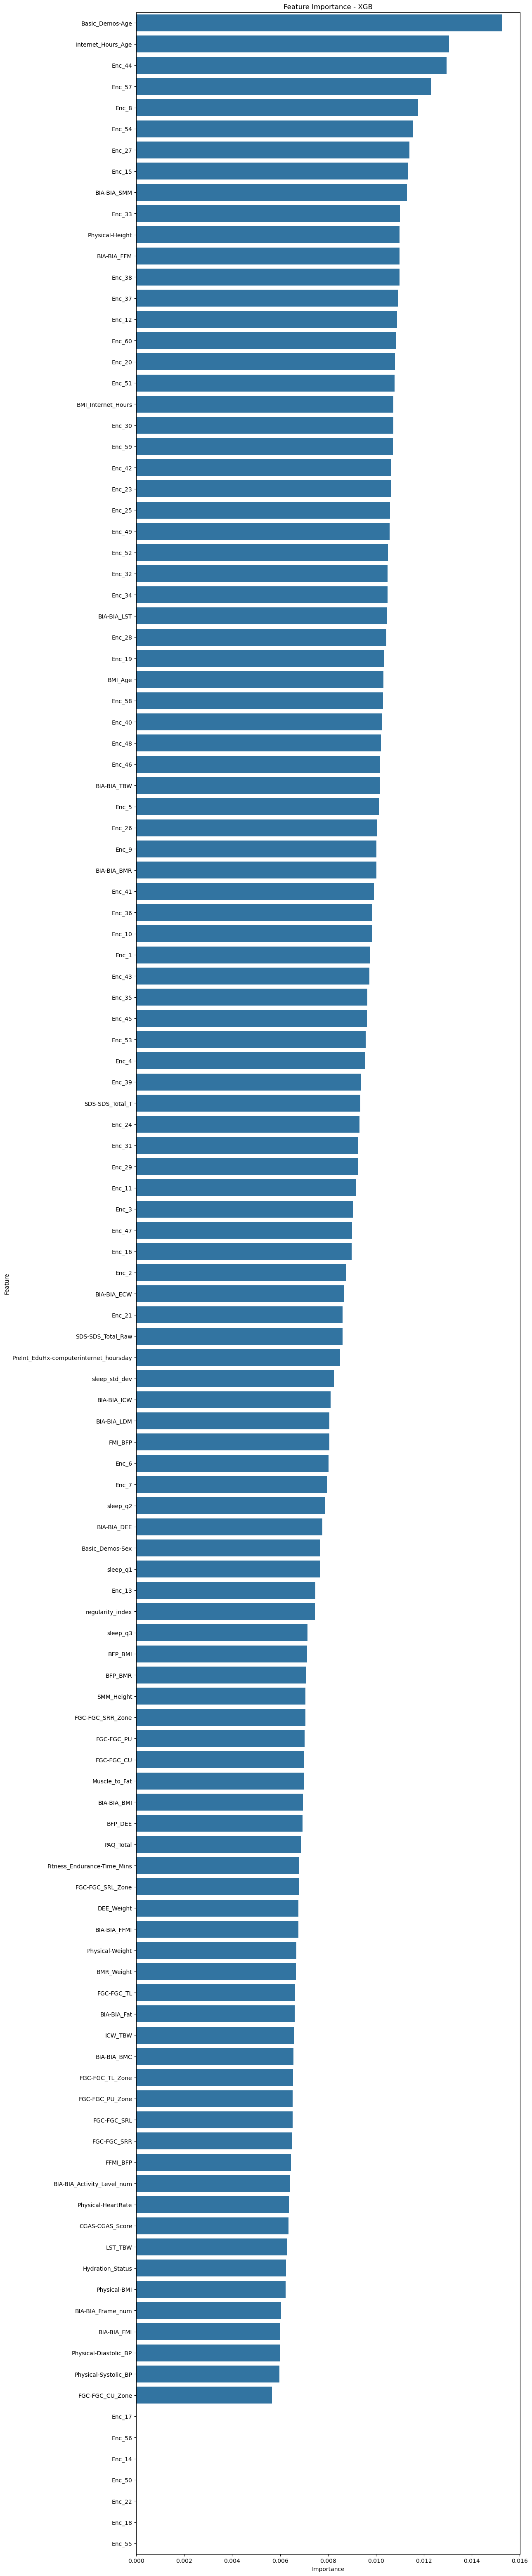

In [16]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_XGB, model_trained_XGB.feature_names_in_, "XGB")

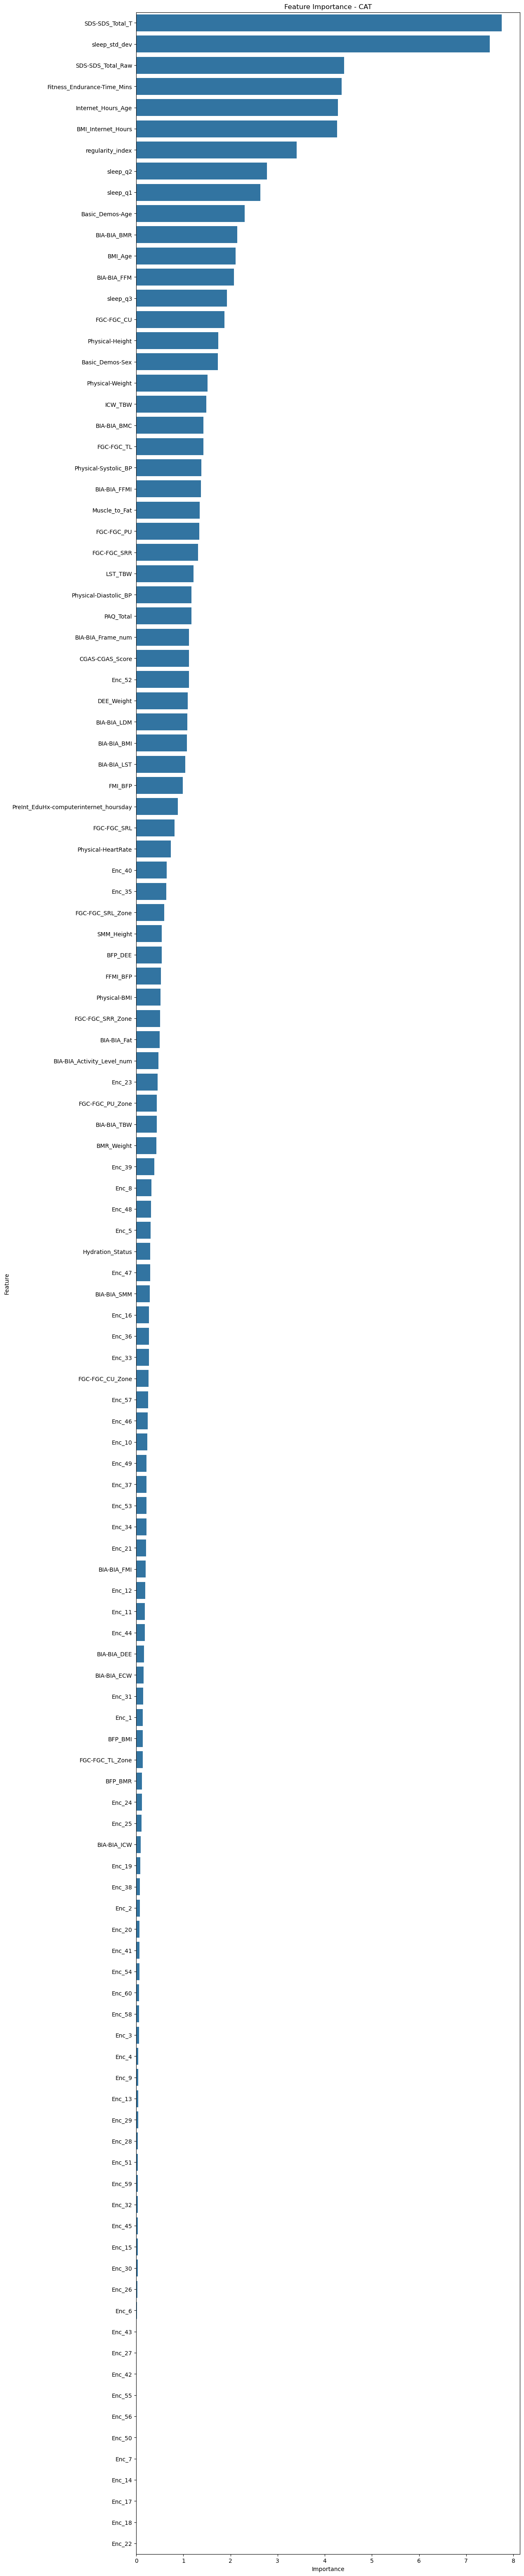

In [17]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_Cat, model_trained_Cat.feature_names_, "CAT")

In [18]:
# 각 모델에 대해 feature importance 시각화
plot_feature_importance(model_trained_ET, model_trained_ET.feature_names_in_, "CAT")

NameError: name 'model_trained_ET' is not defined

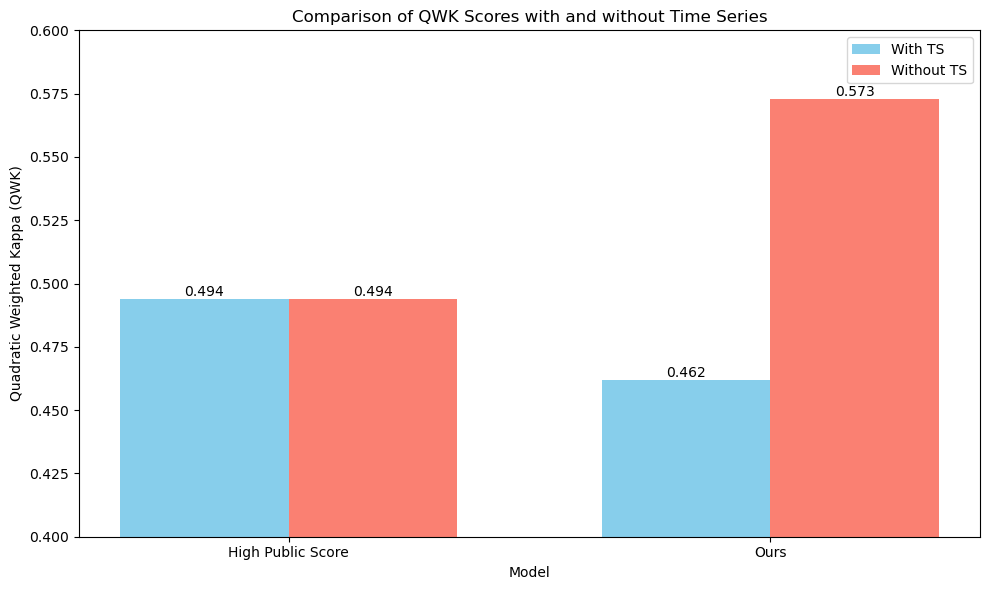

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 모델과 QWK 점수를 정의
models = ['High Public Score', 'Ours']
w_ts = [0.494, 0.462]
wo_ts = [0.494, 0.573]
#0.4735

# 막대 그래프 너비 설정
bar_width = 0.35
index = np.arange(len(models))

# 막대 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 전처리 안한 데이터 막대 그래프
bars1 = ax.bar(index, w_ts, bar_width, label='With TS', color='skyblue')
# 전처리 한 데이터 막대 그래프
bars2 = ax.bar(index + bar_width, wo_ts, bar_width, label='Without TS', color='salmon')

# 각 막대 위에 점수 표시
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

# x축과 y축 레이블 설정
ax.set_xlabel('Model')
ax.set_ylabel('Quadratic Weighted Kappa (QWK)')
ax.set_title('Comparison of QWK Scores with and without Time Series')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(models)
ax.set_ylim(0.4,0.6)

# 범례와 레이아웃 설정
ax.legend()
plt.tight_layout()

# 그래프 표시
plt.show()